In [1]:
import sys
import os
os.chdir('..')
print(os.getcwd())

C:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\CST-Part-II-Project-Code


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json
import seaborn as sns
import copy

In [3]:
def load_data(filepath):
    with open(filepath, 'r') as f:
        return json.load(f)

In [4]:
halving = r".\data\dist3-9data\cc_halving_single_round_3-9_050426.json"
unbounded = r".\data\dist3-9data\cc_unbounded_single_round_3-9_050426.json"
bounded = r".\data\dist3-9data\cc_bounded_single_round_3-9_050426.json"
knn = r".\data\dist3-9data\cc_knn_k=3_single_round_3-9_050426.json"

In [5]:
cc_data_path = r".\data\cc_halving_single_round040426.json"
cc_tri_data_path = r".\data\cc_bounded_nn_single_round040426.json"

In [6]:

def generate_threshold_plots(json_filepath, target_trap_sizes=None):
    print(f"Loading data from {json_filepath}...")
    with open(json_filepath, 'r') as f:
        data = json.load(f)

    logical_rates = data['LogicalErrorRates']['Forwarding']
    phys_x_rates = data['PhysicalXErrorRates']['Forwarding']
    phys_z_rates = data['PhysicalZErrorRates']['Forwarding']

    distances = sorted([int(d) for d in logical_rates.keys()])

    common_capacities = set(logical_rates[str(distances[0])].keys())
    for d in distances[1:]:
        common_capacities &= set(logical_rates[str(d)].keys())
    
    sorted_capacities = sorted(list(common_capacities), key=int)
    print(f"Found common trap sizes: {sorted_capacities}")

    # Select which trap sizes to plot
    if target_trap_sizes is None:
        target_trap_sizes = ['4', '15', '60']
        target_trap_sizes = [t for t in target_trap_sizes if t in sorted_capacities]

    num_plots = len(target_trap_sizes)
    fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 6), squeeze=False)
    axes = axes.flatten()

    markers = {3: 'o', 5: 's', 7: '^'}
    colors = {3: 'blue', 5: 'orange', 7: 'green'}

    for i, trap_size in enumerate(target_trap_sizes):
        ax = axes[i]
        
        for d in distances:
            d_str = str(d)
            
            y_vals = logical_rates[d_str][trap_size]
            
            x_vals_x = phys_x_rates[d_str][trap_size]
            x_vals_z = phys_z_rates[d_str][trap_size]
            x_vals_total = [x + z for x, z in zip(x_vals_x, x_vals_z)]
            x_vals_avg = [i/2.0 for i in x_vals_total]
            

            ax.plot(x_vals_avg, y_vals, 
                    marker=markers.get(d, 'x'), 
                    color=colors.get(d, 'black'), 
                    linestyle='-', 
                    linewidth=2, 
                    markersize=8,
                    label=f'Distance {d}')

        ax.set_title(f'Threshold Plot (Trap Size / Capacity: {trap_size})', fontsize=14)
        ax.set_xlabel('Total Physical Error Rate ($p_x + p_z$)/2', fontsize=12)
        ax.set_ylabel('Logical Error Rate ($P_L$)', fontsize=12)
        ax.set_xscale('log')
        ax.set_yscale('log')
        
        ax.grid(True, which="both", ls="--", alpha=0.5)
        ax.legend(fontsize=11)

    plt.tight_layout()
    
    #output_filename = 'qec_threshold_plots.png'
    #plt.savefig(output_filename, dpi=300)
    #print(f"Plot saved successfully as {output_filename}")
    plt.show()



In [14]:
import json
import matplotlib.pyplot as plt

def plot_qec_thresholds(json_path, target_capacities=None, save_path=None):
    with open(json_path, 'r') as f:
        data = json.load(f)

    # Extract base dictionaries
    log_errs = data.get('LogicalErrorRates', {}).get('Forwarding', {})
    px_errs = data.get('PhysicalXErrorRates', {}).get('Forwarding', {})
    pz_errs = data.get('PhysicalZErrorRates', {}).get('Forwarding', {})

    distances = sorted([int(d) for d in log_errs.keys()])
    
    if not target_capacities:
        caps = set()
        for d in log_errs.values():
            caps.update(d.keys())
        target_capacities = sorted([int(c) for c in caps])
    else:
        target_capacities = [int(c) for c in target_capacities]

    fig, axes = plt.subplots(1, len(target_capacities), figsize=(6 * len(target_capacities), 5), squeeze=False)
    axes = axes.flatten()

    for idx, cap in enumerate(target_capacities):
        ax = axes[idx]
        cap_str = str(cap)
        
        for d in distances:
            d_str = str(d)
            if cap_str in log_errs.get(d_str, {}):
                y_vals = log_errs[d_str][cap_str]
                
                x_vals_x = px_errs.get(d_str, {}).get(cap_str, [0] * len(y_vals))
                x_vals_z = pz_errs.get(d_str, {}).get(cap_str, [0] * len(y_vals))
                x_vals = [x + z for x, z in zip(x_vals_x, x_vals_z)]
                
                pts = sorted(zip(x_vals, y_vals))
                if pts:
                    x_sorted, y_sorted = zip(*pts)
                    ax.plot(x_sorted, y_sorted, marker='o', label=f'Distance {d}')

        # Formatting
        ax.set_title(f'Trap Capacity: {cap}', fontsize=14)
        ax.set_xlabel('Total Physical Error Rate ($P_x + P_z$)', fontsize=12)
        ax.set_ylabel('Logical Error Rate ($P_L$)', fontsize=12)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.grid(True, which='both', ls='--', alpha=0.4)
        ax.legend()

    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
        
    plt.show()

# json_file = 'grid_666_d3-15_tc2-10_2.json'
# plot_qec_thresholds(json_file, target_capacities=[2, 5, 10, 60], save_path='thresholds.png')

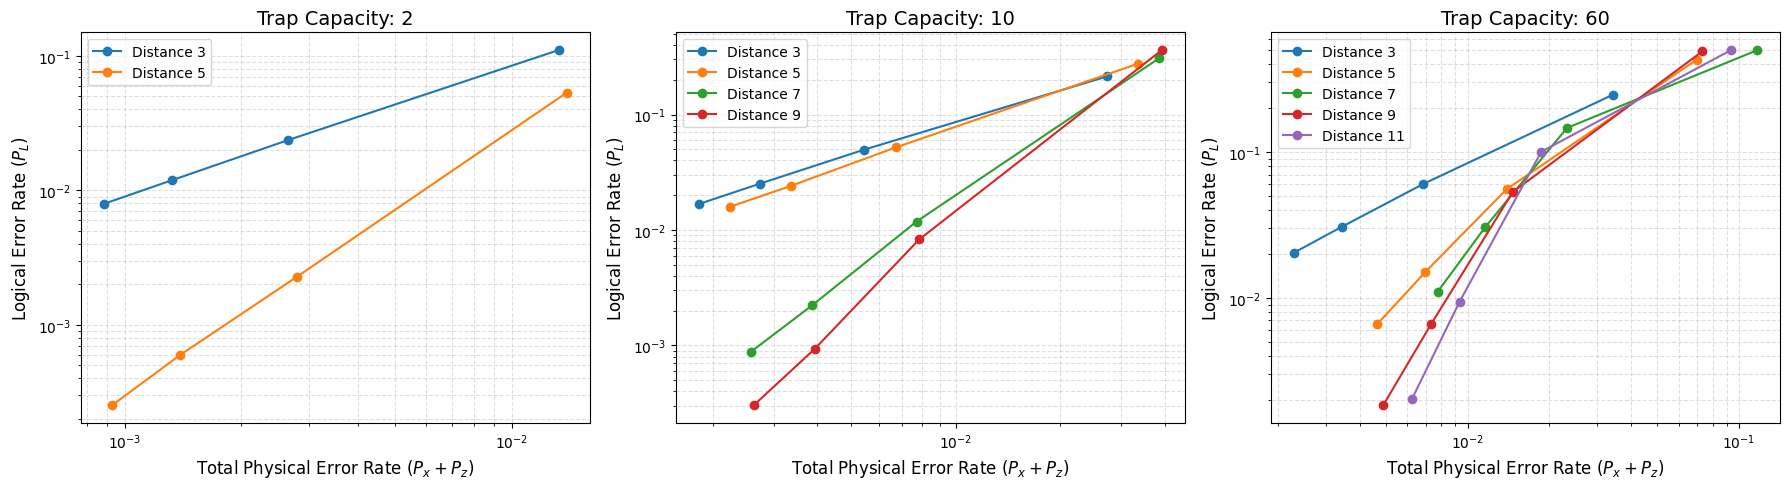

In [17]:
# e.g., target_sizes = ['2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '30', '60', '120']
traps = [2,10,60]
target_sizes = [str(t) for t in traps] 

cc488_grid_data = r'.\data\tctests\tctestgrid488.json'
cc488_switch_data = r'.\data\tctests\tctestswitch488maybe.json'
plot_qec_thresholds(cc488_switch_data, target_capacities = traps)
#generate_threshold_plots(cc488_switch_data, target_trap_sizes=target_sizes)

Loading data from .\data\dist3-9data\cc_halving_single_round_3-9_050426.json...
Found common trap sizes: ['2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '30', '60', '120']


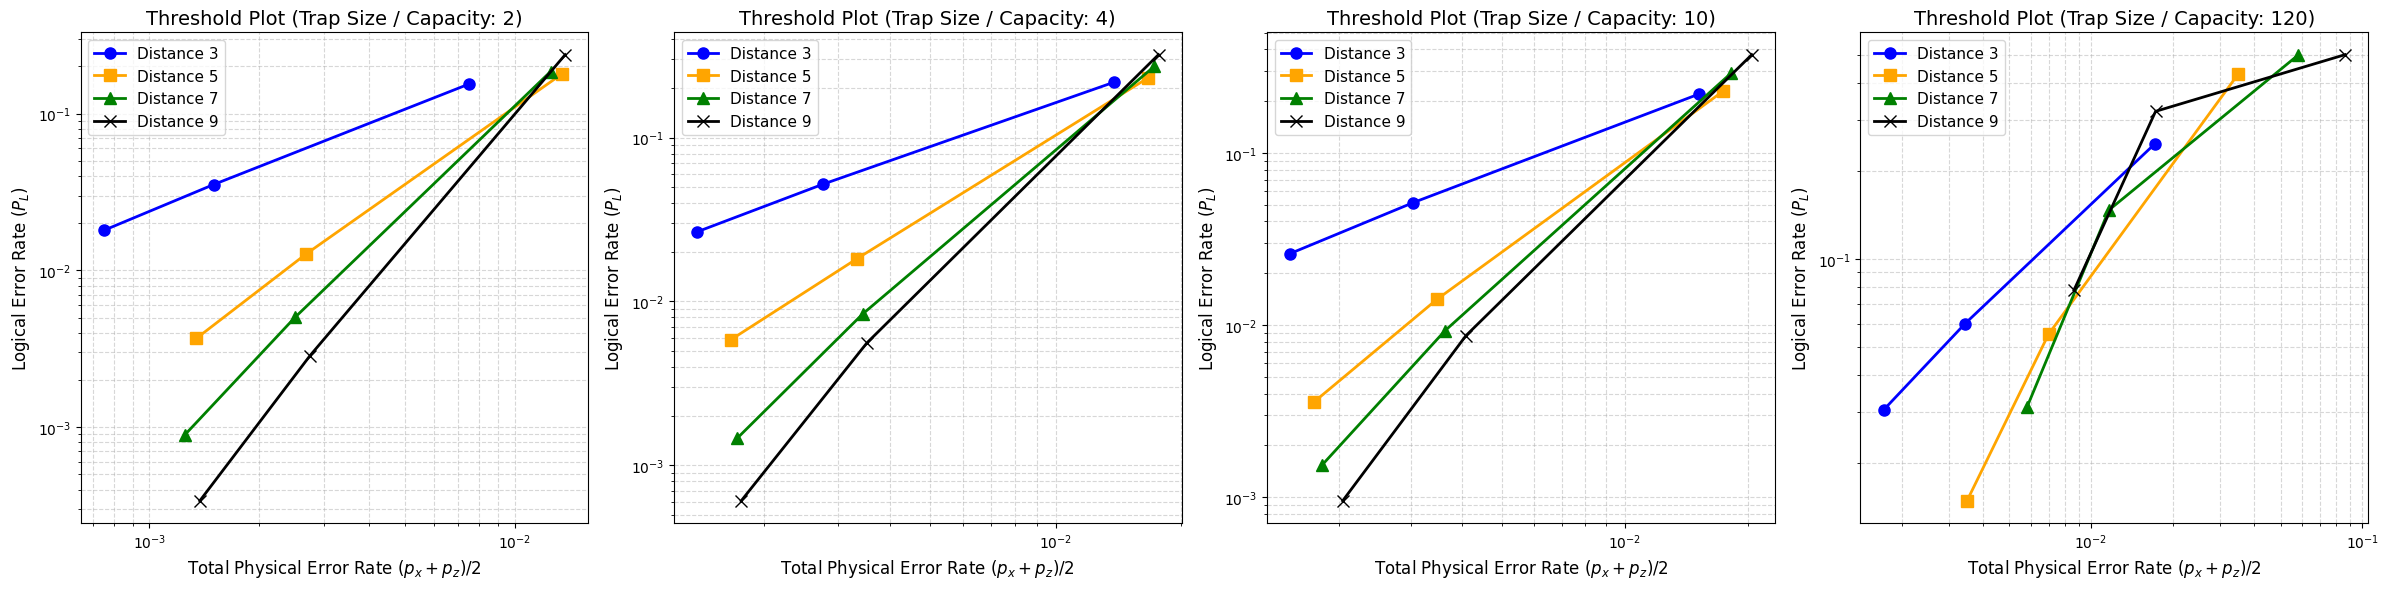

Loading data from .\data\dist3-9data\cc_bounded_single_round_3-9_050426.json...
Found common trap sizes: ['2', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '30', '60', '120']


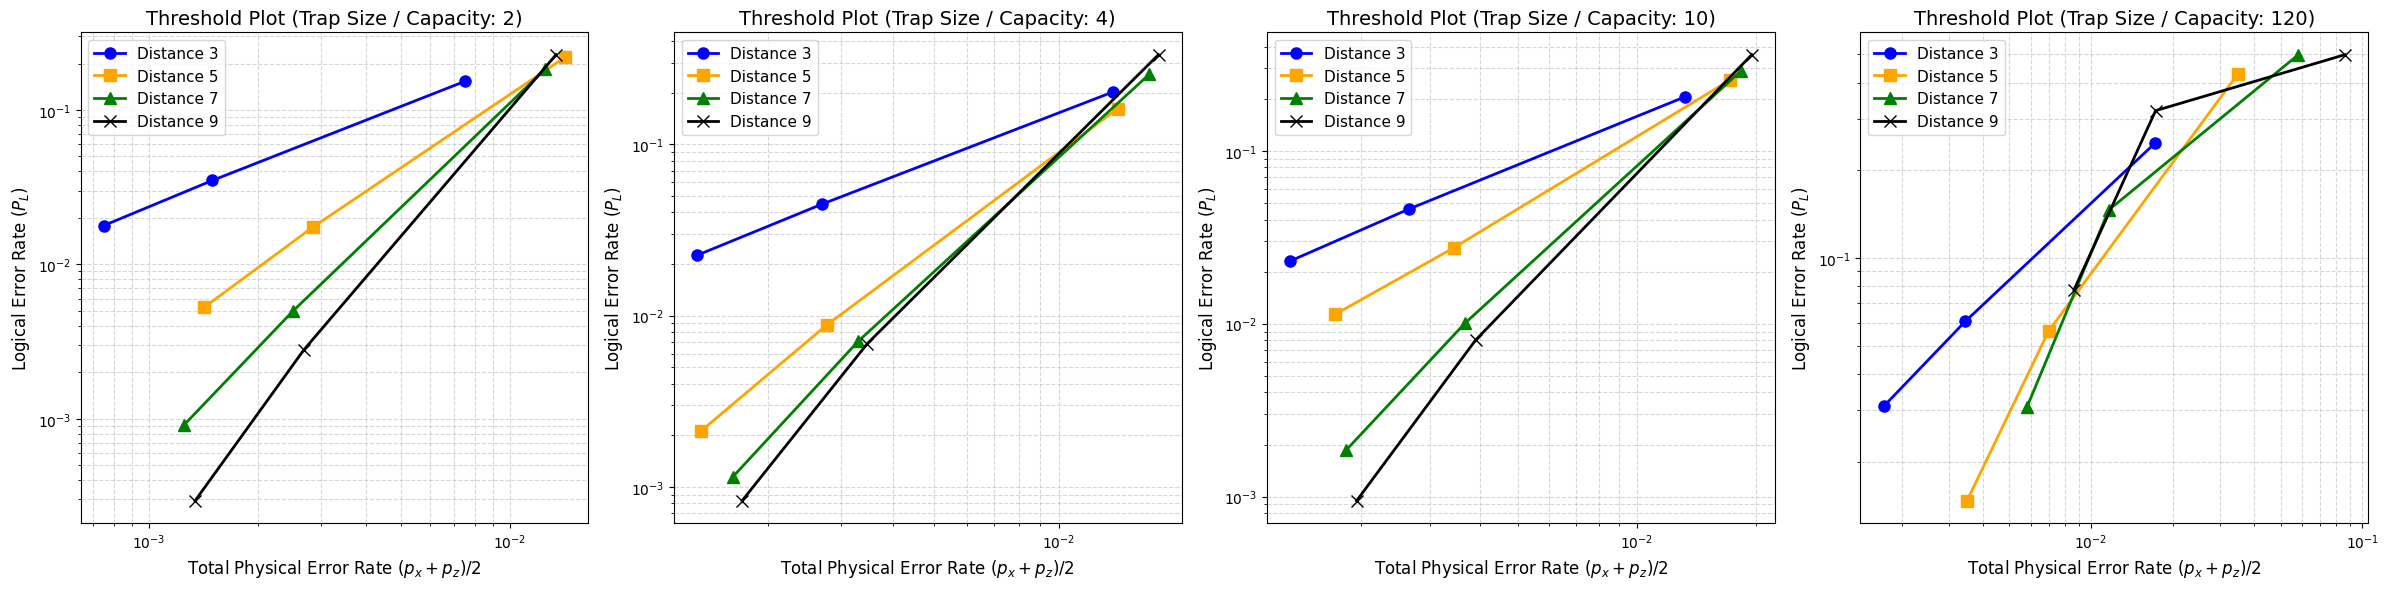

In [8]:
target_sizes = ['2', '4', '10', '120'] 

generate_threshold_plots(halving, target_trap_sizes=target_sizes)
generate_threshold_plots(bounded, target_trap_sizes=target_sizes)

In [20]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import math

def generate_log_ratio_heatmaps(json_baseline, json_new, label_baseline="Normal", label_new="Sierpinski"):
    
    data_baseline = load_data(json_baseline)['LogicalErrorRates']['Forwarding']
    data_new = load_data(json_new)['LogicalErrorRates']['Forwarding']

    all_distances = set(data_baseline.keys()).union(set(data_new.keys()))
    distances = sorted([int(d) for d in all_distances])
    
    all_capacities = set()
    for dist_dict in data_baseline.values():
        all_capacities.update(dist_dict.keys())
    for dist_dict in data_new.values():
        all_capacities.update(dist_dict.keys())
        
    capacities_int = sorted([int(c) for c in all_capacities], reverse=True)
    capacities = [str(c) for c in capacities_int]

    num_gate_improvements = 0
    for d in data_baseline.values():
        for c in d.values():
            num_gate_improvements = max(num_gate_improvements, len(c))
    gate_improvements = [1.0, 5.0, 10.0]
    
    for factor_idx in range(num_gate_improvements):
        heatmap_data = []

        for cap in capacities:
            row = []
            for dist in distances:
                dist_str = str(dist)
                
                rates_base = data_baseline.get(dist_str, {}).get(cap)
                rates_new = data_new.get(dist_str, {}).get(cap)
                
                if (rates_base is not None and rates_new is not None and 
                    len(rates_base) > factor_idx and len(rates_new) > factor_idx):
                    
                    val_base = rates_base[factor_idx]
                    val_new = rates_new[factor_idx]
                    
                    if val_base == 0 or val_new == 0:
                        log_ratio = np.nan
                    else:
                        log_ratio = np.log10(val_new / val_base)
                else:
                    log_ratio = np.nan
                    
                row.append(log_ratio)
                
            heatmap_data.append(row)

        df = pd.DataFrame(heatmap_data, index=capacities, columns=distances)

        annot_array = np.empty_like(df.values, dtype=object)
        for i in range(df.shape[0]):
            for j in range(df.shape[1]):
                val = df.iloc[i, j]
                if pd.isna(val):
                    annot_array[i, j] = "NaN"
                else:
                    factor = 10 ** (-val)
                    annot_array[i, j] = f"{factor:.2f}x"

        plt.figure(figsize=(10, 8))
        
        cmap = copy.copy(plt.get_cmap("vlag"))
        cmap.set_bad("darkgray") 

        max_abs_val = df.abs().max().max()
        limit = min(max_abs_val, 2.0)
        
        max_tick = math.ceil(limit)
        cbar_ticks = np.arange(-max_tick, max_tick + 1, 1.0) # e.g., [-2.0, -1.0, 0.0, 1.0, 2.0]

        ax = sns.heatmap(df, 
                    annot=annot_array, 
                    fmt="",            
                    cmap=cmap, 
                    center=0,
                    vmin=-limit,
                    vmax=limit,
                    cbar_kws={'label': 'Relative Improvement Multiplier', 'ticks': cbar_ticks},
                    linewidths=.5)

        cbar = ax.collections[0].colorbar
        tick_labels = []
        for tick_val in cbar_ticks:
            factor = 10 ** (-tick_val)
            if factor >= 1:
                tick_labels.append(f"{factor:.0f}x")
            else:
                tick_labels.append(f"{factor:g}x")
                
        cbar.set_ticklabels(tick_labels)

        plt.title(f'{label_new} vs {label_baseline}: Relative Improvement (Gate Imprv. {gate_improvements[factor_idx]}x)', fontsize=13, pad=15)
        plt.xlabel('Code Distance ($d$)', fontsize=12)
        plt.ylabel('Capacity', fontsize=12)

        plt.tight_layout()
        if factor_idx == 1:
            output_filename = f'heatmap_improvement_factor_{gate_improvements[factor_idx]}_{label_new.replace(" ", "_")}.png'
            plt.savefig(output_filename, dpi=300)
            print(f"Saved: {output_filename}")
        
        plt.show()

# generate_log_ratio_heatmaps('normal.json', 'sierpinski.json')

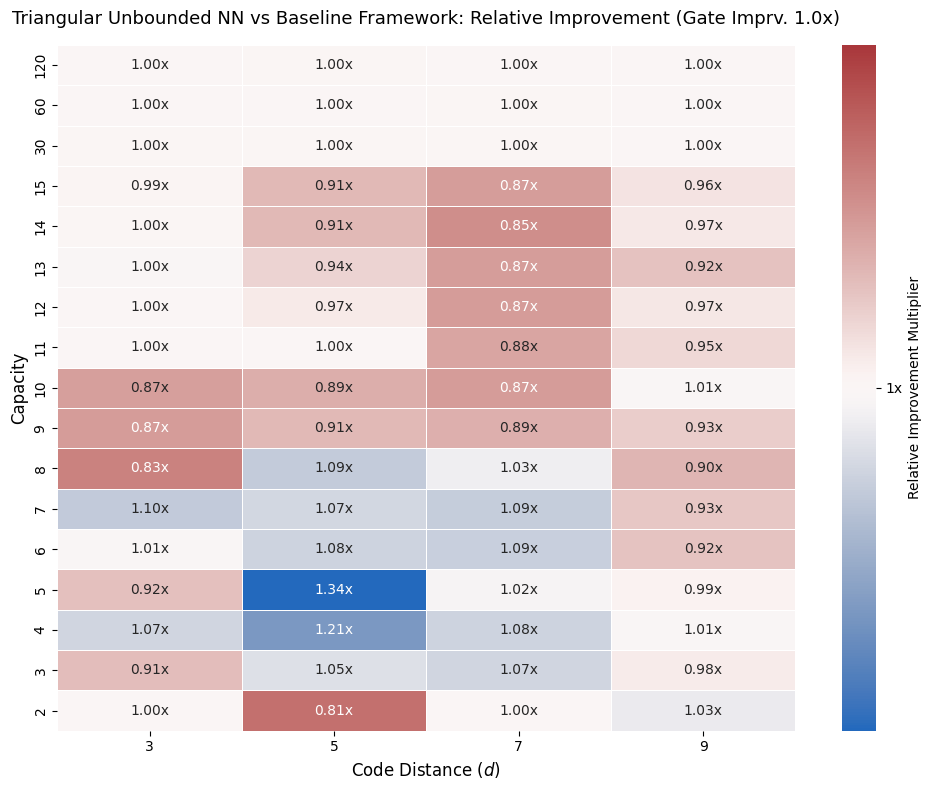

Saved: heatmap_improvement_factor_5.0_Triangular_Unbounded_NN.png


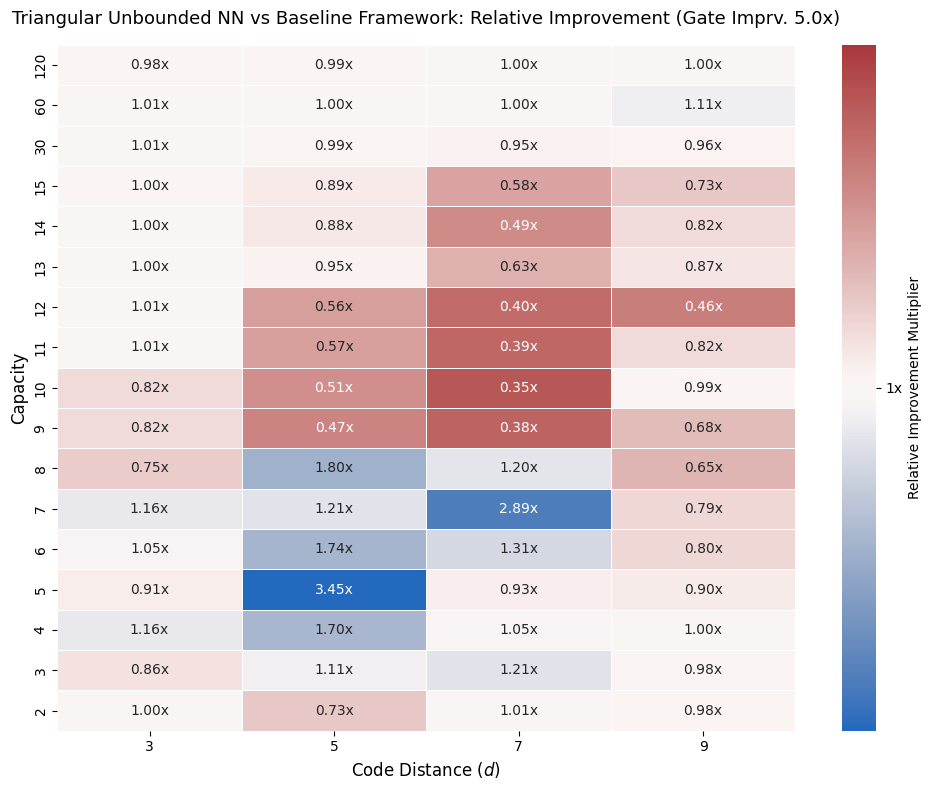

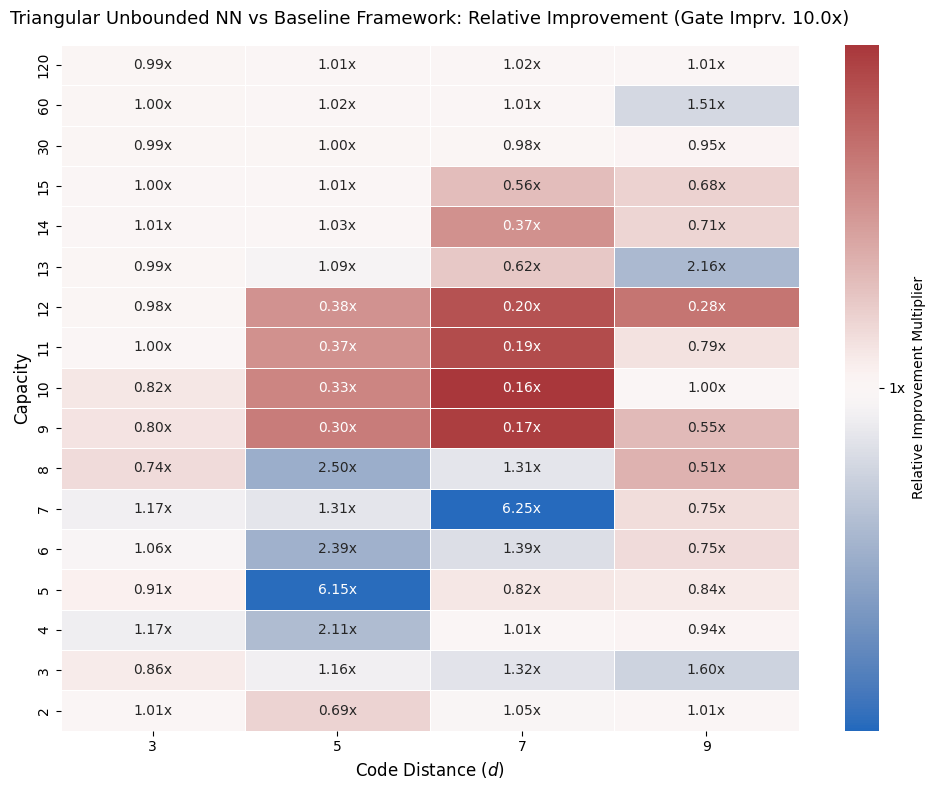

In [21]:
#heatmap generation for 1-round circuit baseline vs unbounded

generate_log_ratio_heatmaps(halving, unbounded, label_baseline="Baseline Framework", label_new="Triangular Unbounded NN")

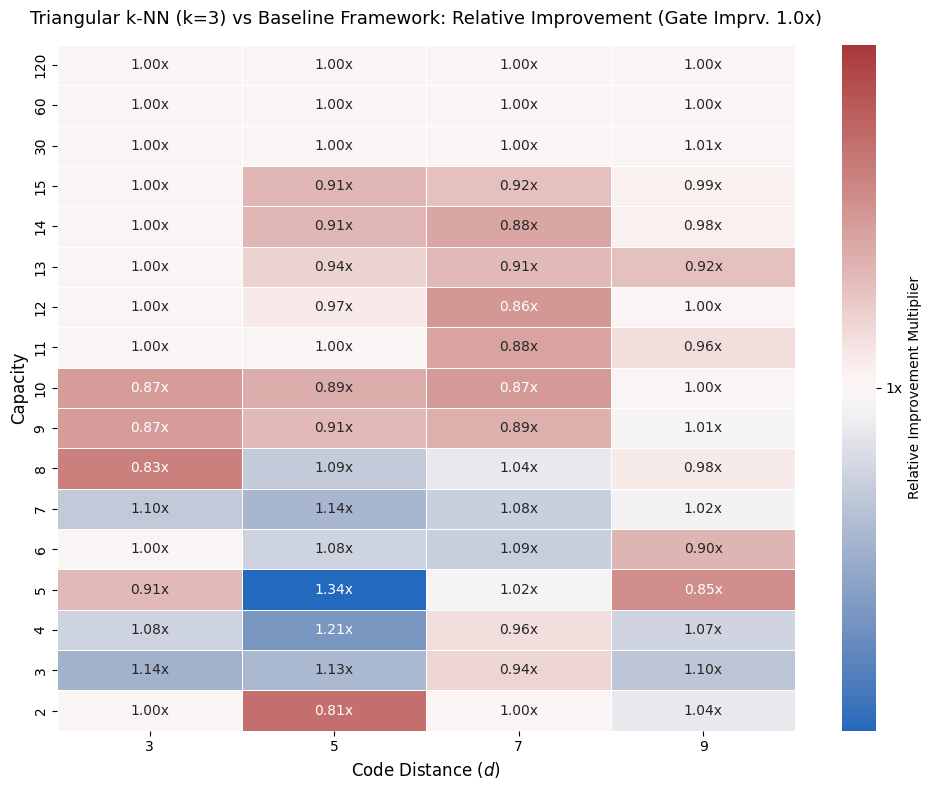

Saved: heatmap_improvement_factor_5.0_Triangular_k-NN_(k=3).png


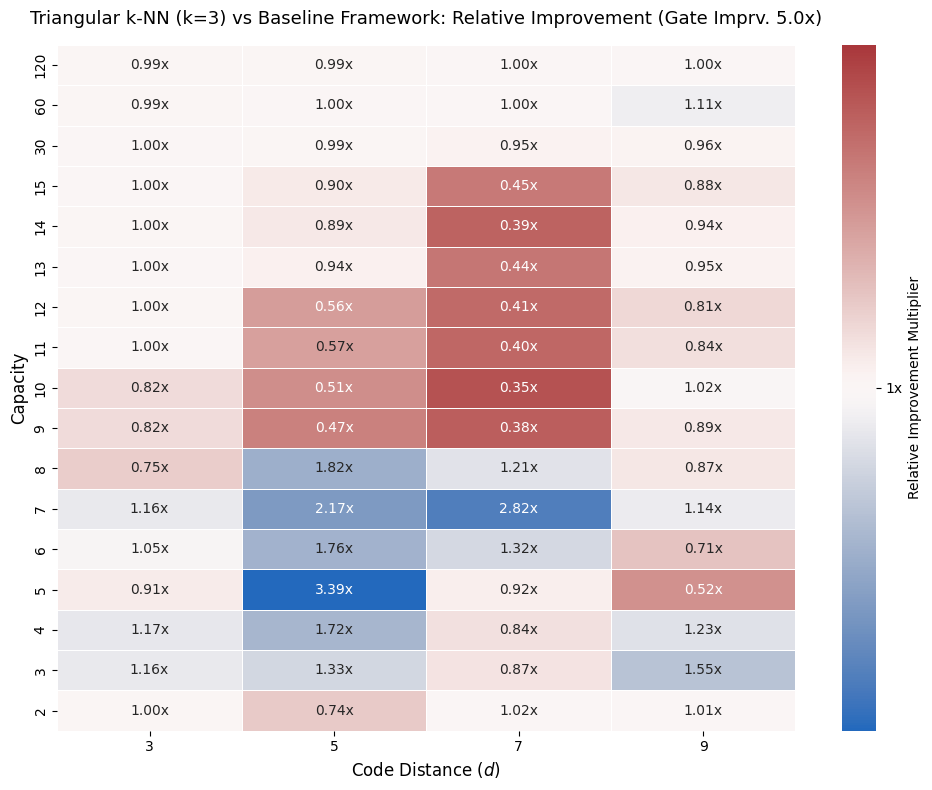

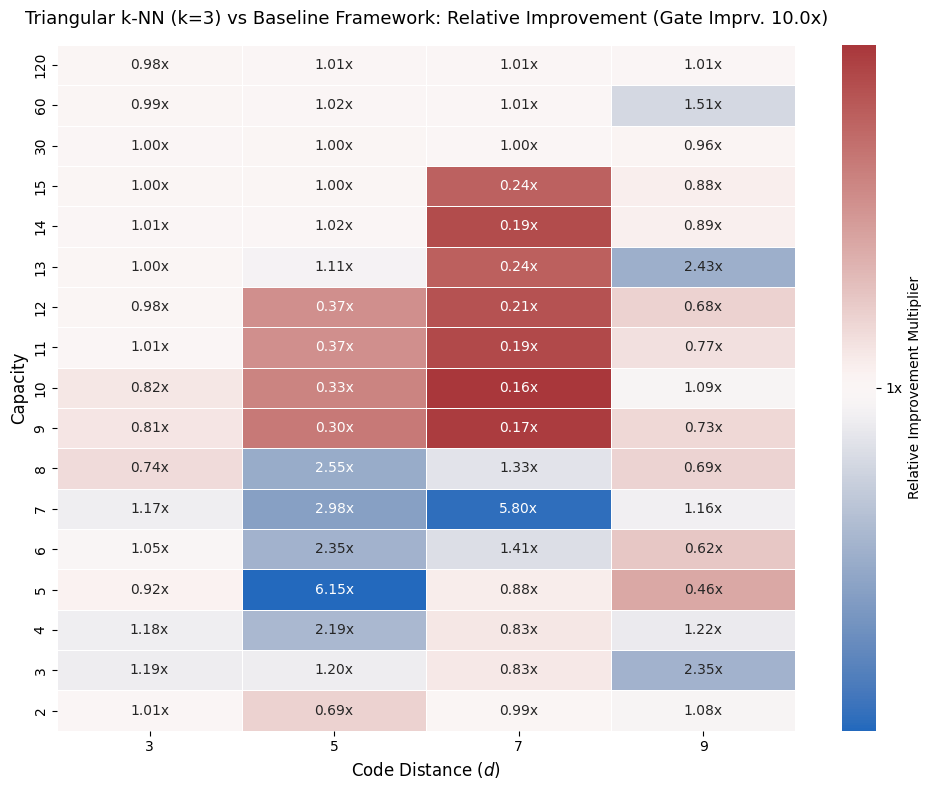

In [22]:
#heatmap generation for 1-round circuit baseline vs knn

generate_log_ratio_heatmaps(halving, knn, label_baseline="Baseline Framework", label_new="Triangular k-NN (k=3)")

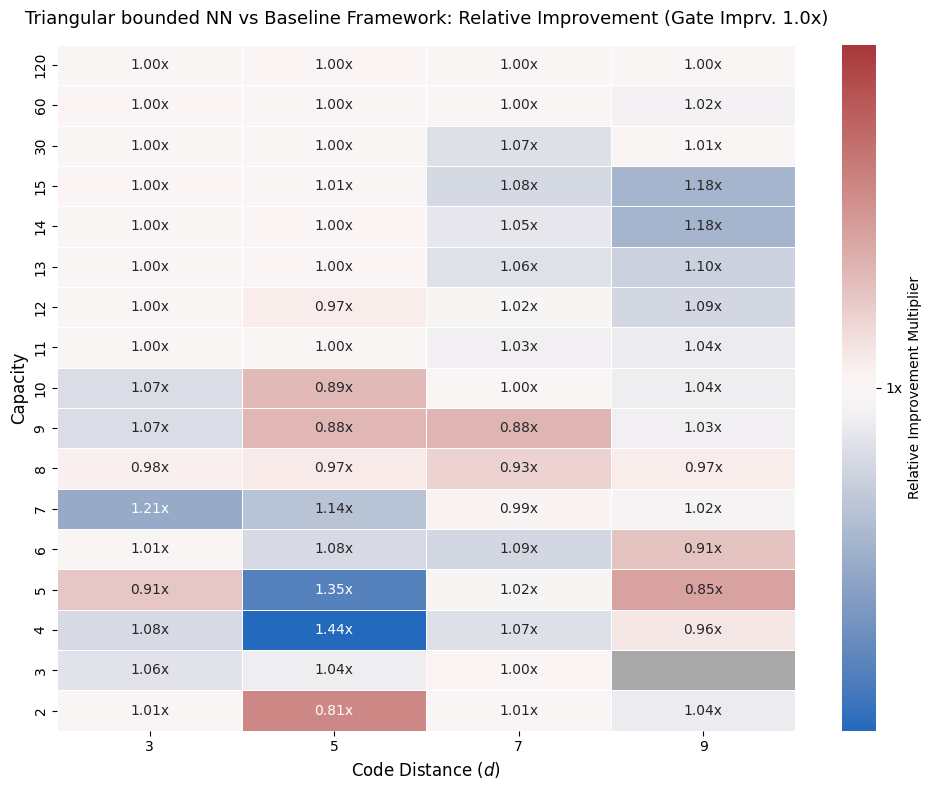

Saved: heatmap_improvement_factor_5.0_Triangular_bounded_NN.png


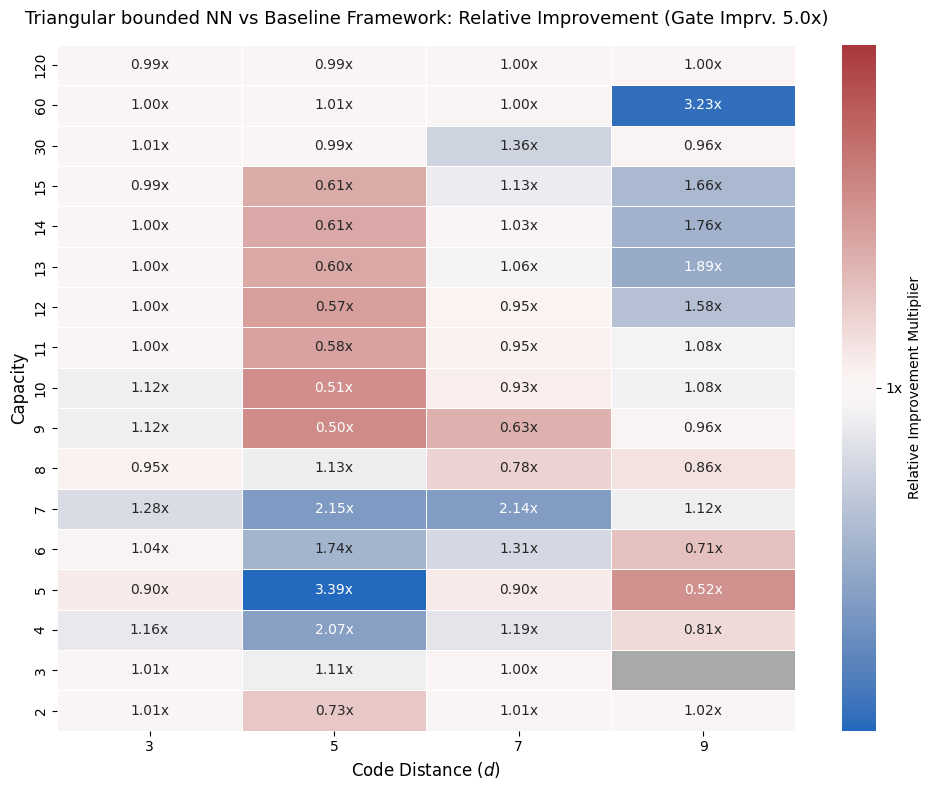

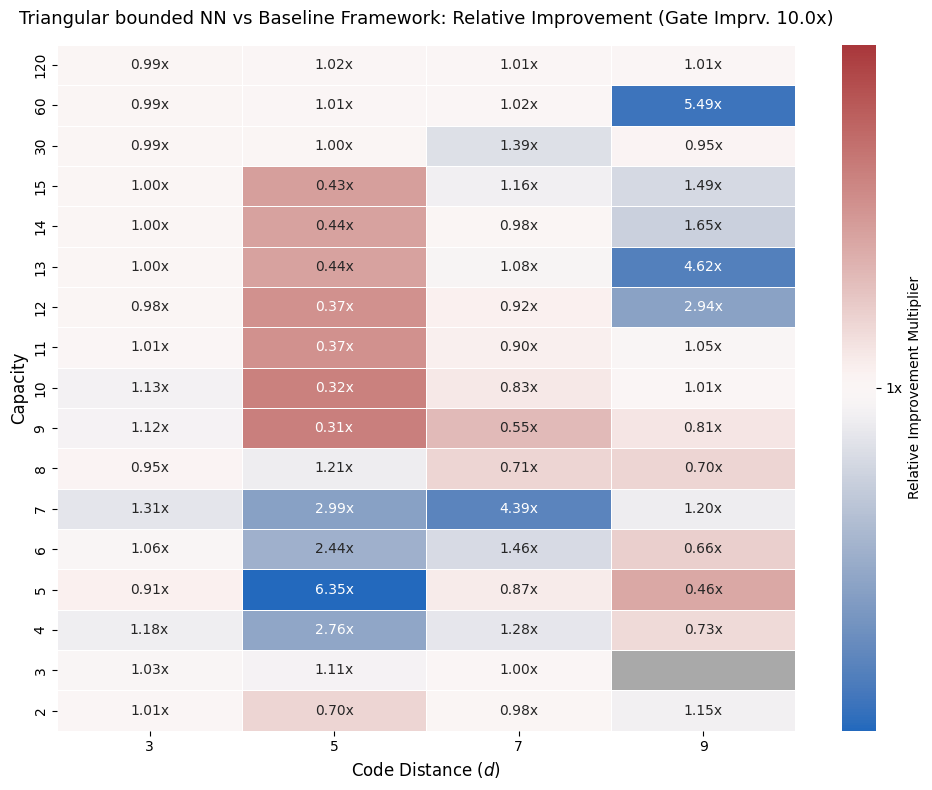

In [23]:
#heatmap generation for single round circuit baseline vs bounded

generate_log_ratio_heatmaps(halving, bounded, label_baseline="Baseline Framework", label_new="Triangular bounded NN")

In [22]:

def get_global_keys(datasets):
    """Safely extracts all unique distances and capacities across multiple datasets."""
    all_distances = set()
    all_capacities = set()
    
    for data in datasets:
        all_distances.update(data.keys())
        for dist_dict in data.values():
            all_capacities.update(dist_dict.keys())
            
    distances = sorted([int(d) for d in all_distances])
    capacities_int = sorted([int(c) for c in all_capacities], reverse=True)
    capacities = [str(c) for c in capacities_int]
    
    return distances, capacities

def generate_1x3_log_ratio_heatmaps(json_baseline, json_alt1, json_alt2, json_alt3, 
                                    label_base="Baseline", labels_alt=["Alt 1", "Alt 2", "Alt 3"]):
    d_base = load_data(json_baseline)['LogicalErrorRates']['Forwarding']
    d_alt1 = load_data(json_alt1)['LogicalErrorRates']['Forwarding']
    d_alt2 = load_data(json_alt2)['LogicalErrorRates']['Forwarding']
    d_alt3 = load_data(json_alt3)['LogicalErrorRates']['Forwarding']
    
    datasets = [d_base, d_alt1, d_alt2, d_alt3]
    alts = [d_alt1, d_alt2, d_alt3]
    
    distances, capacities = get_global_keys(datasets)
    
    num_gate_improvements = 0
    for d in d_base.values():
        for c in d.values():
            num_gate_improvements = max(num_gate_improvements, len(c))
    gate_imprv = [1.0, 5.0, 10.0]

    for factor_idx in range(num_gate_improvements):
        dfs = []
        annot_arrays = []
        
        # calc Log10 Ratios for all 3 methods
        for alt_data in alts:
            heatmap_data = []
            for cap in capacities:
                row = []
                for dist in distances:
                    dist_str = str(dist)
                    
                    r_base = d_base.get(dist_str, {}).get(cap)
                    r_new = alt_data.get(dist_str, {}).get(cap)
                    
                    if (r_base is not None and r_new is not None and 
                        len(r_base) > factor_idx and len(r_new) > factor_idx):
                        
                        val_base = r_base[factor_idx]
                        val_new = r_new[factor_idx]
                        
                        if val_base == 0 or val_new == 0:
                            log_ratio = np.nan
                        else:
                            log_ratio = np.log10(val_new / val_base)
                    else:
                        log_ratio = np.nan
                        
                    row.append(log_ratio)
                heatmap_data.append(row)
            
            df = pd.DataFrame(heatmap_data, index=capacities, columns=distances)
            dfs.append(df)
            
            annot = np.empty_like(df.values, dtype=object)
            for i in range(df.shape[0]):
                for j in range(df.shape[1]):
                    val = df.iloc[i, j]
                    if pd.isna(val):
                        annot[i, j] = "NaN"
                    else:
                        annot[i, j] = f"{val:.2f}"
            annot_arrays.append(annot)

        max_abs_vals = [df.abs().max().max() for df in dfs]
        global_max = max(max_abs_vals)

        limit = min(global_max, 2.0) 
        if pd.isna(limit): 
            limit = 1.0

        fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharey=True)
        
        cmap = copy.copy(plt.get_cmap("vlag"))
        cmap.set_bad("darkgray")

        for i, ax in enumerate(axes):
            show_cbar = (i == 2) 
            
            sns.heatmap(dfs[i], 
                        ax=ax,
                        annot=annot_arrays[i], 
                        fmt="",            
                        cmap=cmap, 
                        center=0,
                        vmin=-limit,    
                        vmax=limit,     
                        cbar=show_cbar,
                        cbar_kws={'label': 'Log10 Ratio (Orders of Magnitude)'} if show_cbar else None,
                        linewidths=.5)

            ax.set_title(f'{labels_alt[i]} vs {label_base}', fontsize=14, pad=10)
            ax.set_xlabel('Code Distance ($d$)', fontsize=12)
            

            if i == 0:
                ax.set_ylabel('Capacity', fontsize=12)

        fig.suptitle(f'Comparative QEC Mapping Performance (Gate Improvement {gate_imprv[factor_idx]})', fontsize=16, y=1.02)

        plt.tight_layout()
        if factor_idx == 1:
            output_filename = f'heatmap_1x3_logratio_factor_gate_imprv_{gate_imprv[factor_idx]}.png'
            plt.savefig(output_filename, bbox_inches="tight", dpi=300)
            print(f"Saved: {output_filename}")
        
        plt.show()



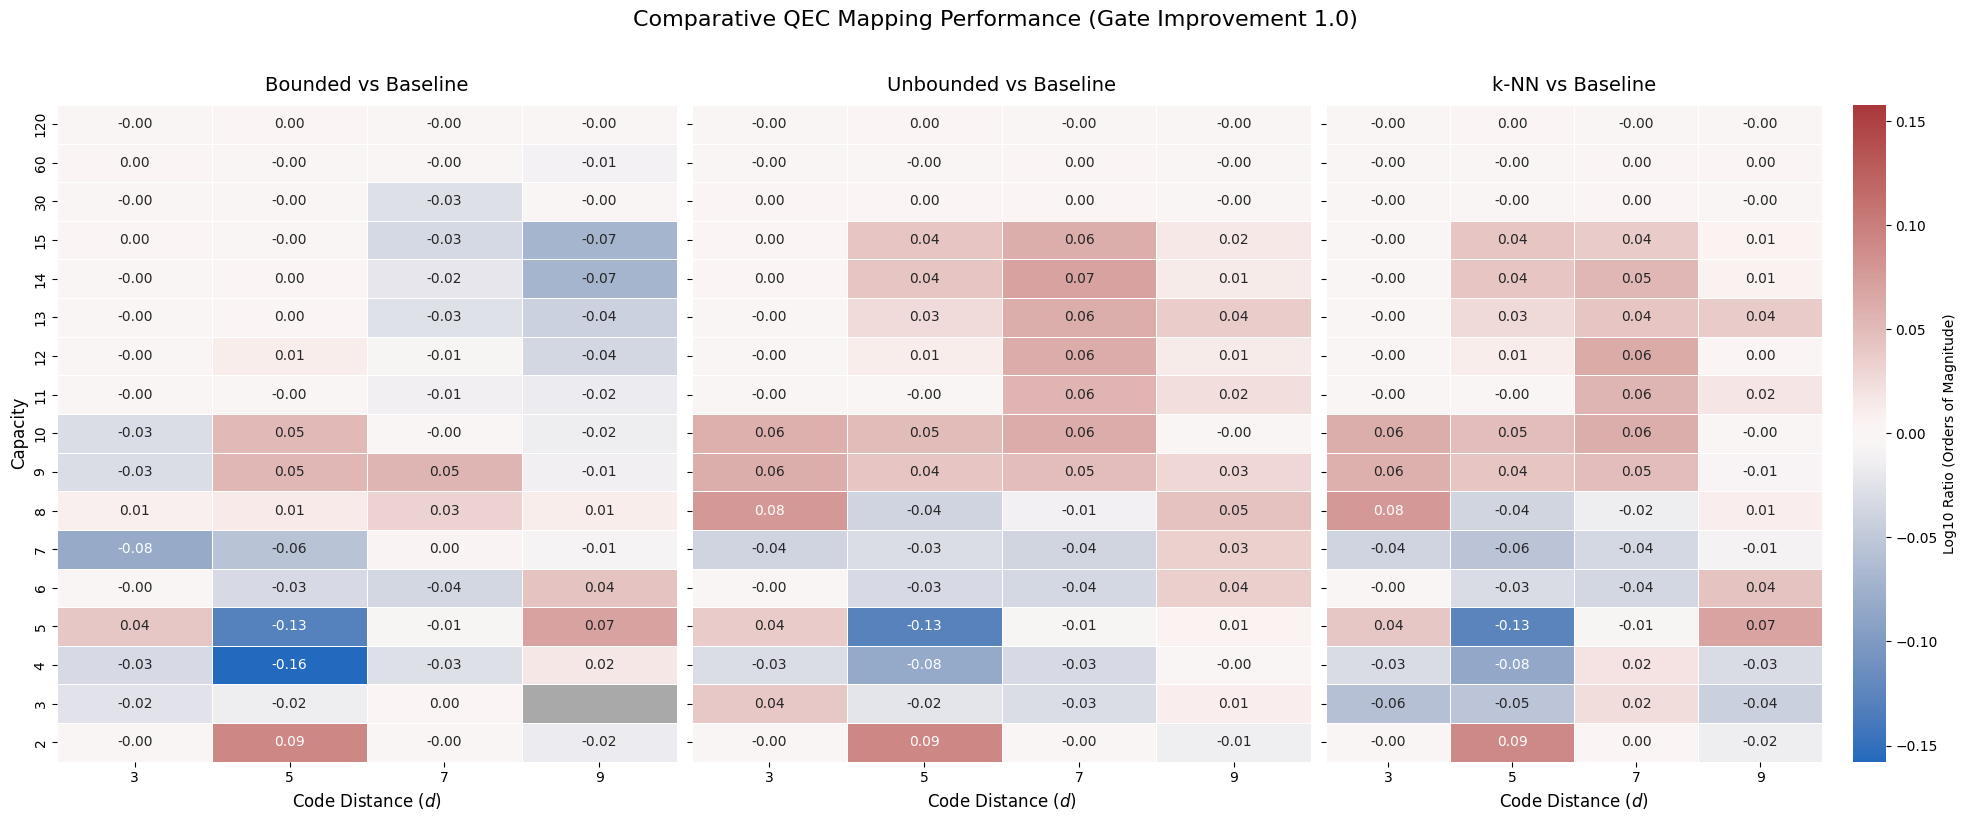

Saved: heatmap_1x3_logratio_factor_gate_imprv_5.0.png


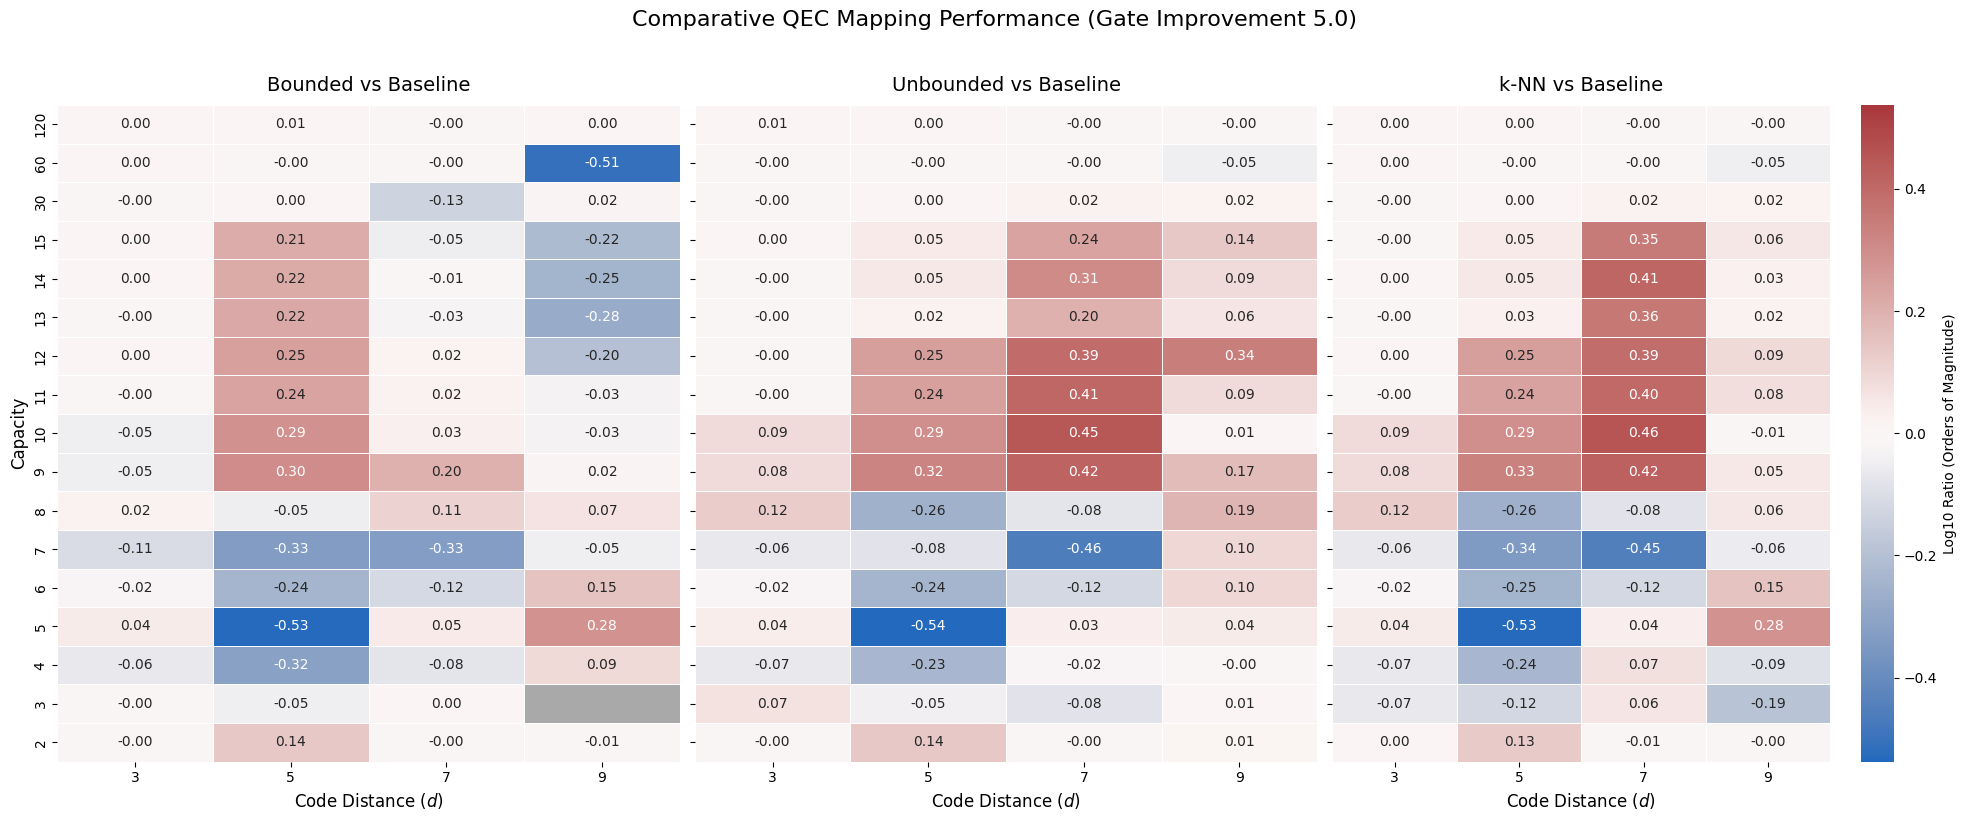

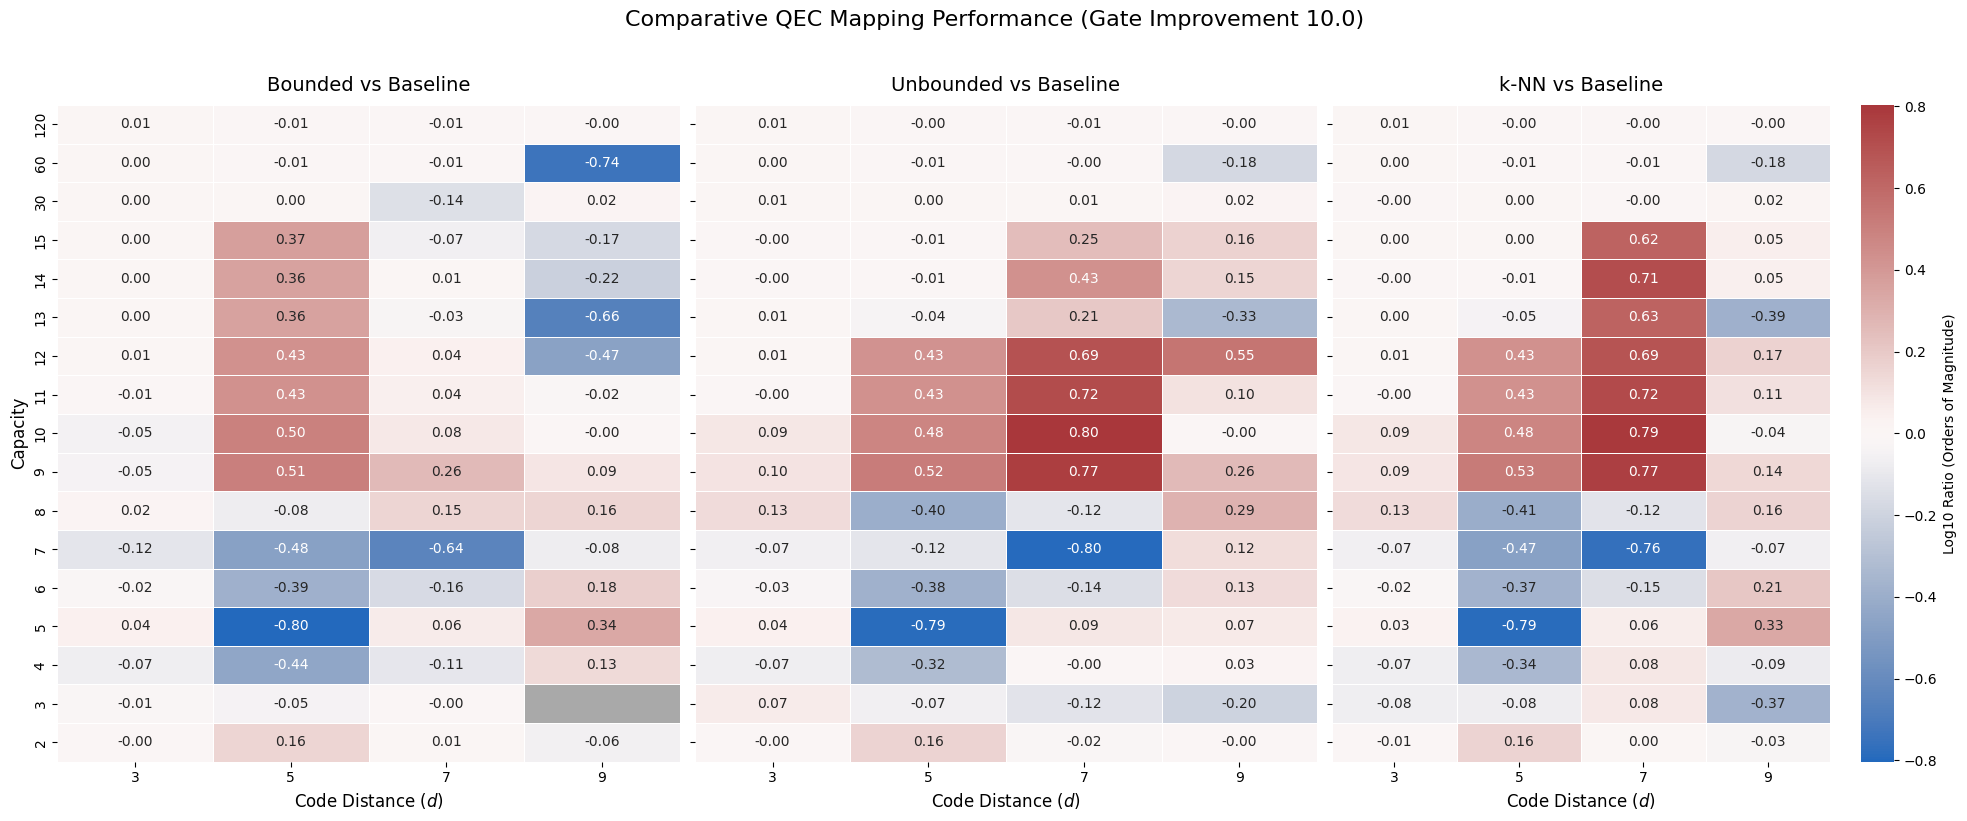

In [23]:
labels = ["Bounded", "Unbounded", "k-NN"]

generate_1x3_log_ratio_heatmaps(halving, bounded, unbounded, knn, label_base="Baseline", labels_alt=labels)

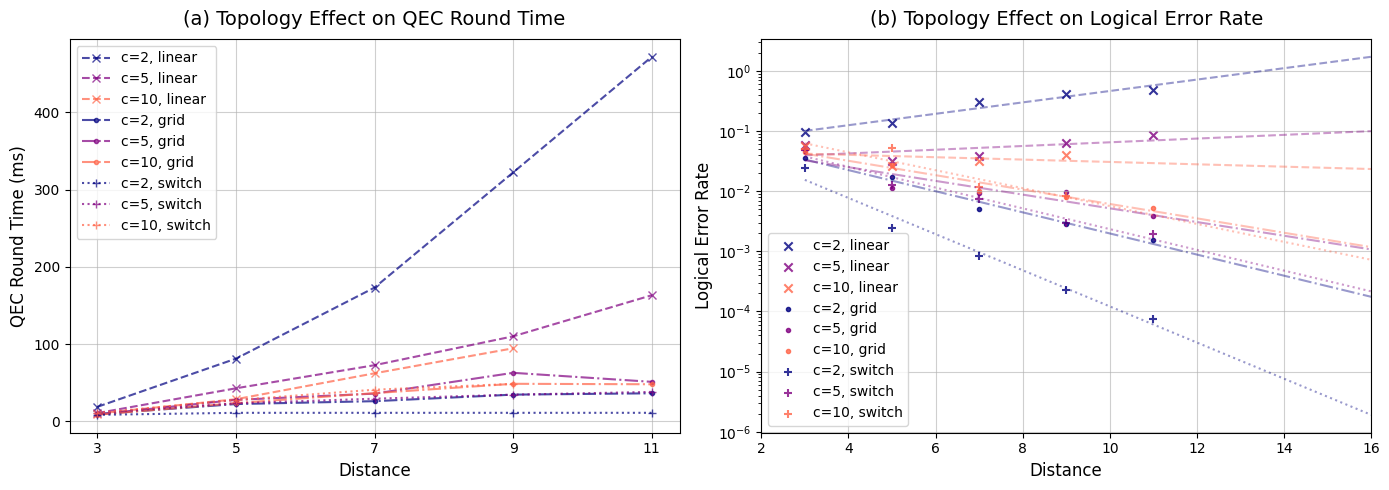

In [4]:
import json
import numpy as np
import matplotlib.pyplot as plt

def load_data(filepath):
    with open(filepath, 'r') as f:
        return json.load(f)

grid_data = load_data(r'.\data\topologytestdata\grid_666_d3-15_tc2-10.json')
linear_data = load_data(r'.\data\topologytestdata\linear_666_d3-11_tc2-30new.json') 
switch_data = load_data(r'.\data\topologytestdata\networked_666_d3-11_tc2-30.json') 

# Configuration vars
target_capacities = ['2', '5', '10']
target_distances = [3, 5, 7, 9, 11]
factor_idx = 2  # 0 = 1.0x, 1 = 2.5x, 2 = 5.0x

extrapolate_distance = 16

colors = {'2': 'navy', '5': 'purple', '10':'tomato' }
#colors = {'2': 'navy', '5':'darkorange','10':'crimson'}
markers = {'linear': 'x', 'grid': '.', 'switch': '+'}
linestyles = {'linear': '--', 'grid': '-.', 'switch': ':'}

def extract_metric(data, metric, distances, capacities, factor_index=None):
    """Safely extracts metrics, returning valid distances and their corresponding values."""
    extracted = {cap: {'d': [], 'val': []} for cap in capacities}
    
    for d in distances:
        d_str = str(d)
        if d_str in data[metric]['Forwarding']:
            for cap in capacities:
                if cap in data[metric]['Forwarding'][d_str]:
                    val = data[metric]['Forwarding'][d_str][cap]
                    if factor_index is not None:
                        if isinstance(val, list) and len(val) > factor_index:
                            
                            val = val[factor_index]
                        else:
                            continue
                            
                    extracted[cap]['d'].append(d)
                    extracted[cap]['val'].append(val)
                    
    return extracted

grid_times = extract_metric(grid_data, 'ElapsedTime', target_distances, target_capacities)
linear_times = extract_metric(linear_data, 'ElapsedTime', target_distances, target_capacities)
switch_times = extract_metric(switch_data, 'ElapsedTime', target_distances, target_capacities)

grid_errors = extract_metric(grid_data, 'LogicalErrorRates', target_distances, target_capacities, factor_idx)
linear_errors = extract_metric(linear_data, 'LogicalErrorRates', target_distances, target_capacities, 1)
switch_errors = extract_metric(switch_data, 'LogicalErrorRates', target_distances, target_capacities, factor_idx)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

def plot_times(time_dict, topo_name):
    for cap in target_capacities:
        if len(time_dict[cap]['d']) > 0:
            vals_ms = [v * 1000 for v in time_dict[cap]['val']]
            ax1.plot(time_dict[cap]['d'], vals_ms, color=colors[cap], marker=markers[topo_name], 
                     linestyle=linestyles[topo_name], label=f'c={cap}, {topo_name}', alpha=0.7)

plot_times(linear_times, 'linear')
plot_times(grid_times, 'grid')
plot_times(switch_times, 'switch')

ax1.set_title('(a) Topology Effect on QEC Round Time', fontsize=14, pad=10)
ax1.set_xlabel('Distance', fontsize=12)
ax1.set_ylabel('QEC Round Time (ms)', fontsize=12)
ax1.set_xticks(target_distances)
ax1.grid(True, linestyle='-', alpha=0.6)
ax1.legend()

def plot_error_fit(data_dict, topo_name):
    for cap in target_capacities:
        d_vals = np.array(data_dict[cap]['d'])
        p_vals = np.array(data_dict[cap]['val'])
        
        if len(d_vals) > 0:
            ax2.scatter(d_vals, p_vals, color=colors[cap], marker=markers[topo_name], alpha=0.8, label=f'c={cap}, {topo_name}')
            
            if len(d_vals) >= 2:
                valid_mask = p_vals > 0
                if sum(valid_mask) >= 2:
                    m, c = np.polyfit(d_vals[valid_mask], np.log10(p_vals[valid_mask]), 1)
                    
                    extended_d_vals = np.linspace(min(d_vals), extrapolate_distance, 50)
                    extended_fit_vals = 10**(m * extended_d_vals + c)
                    
                    ax2.plot(extended_d_vals, extended_fit_vals, color=colors[cap], 
                             linestyle=linestyles[topo_name], alpha=0.4)

plot_error_fit(linear_errors, 'linear')
plot_error_fit(grid_errors, 'grid')
plot_error_fit(switch_errors, 'switch')

ax2.set_title('(b) Topology Effect on Logical Error Rate', fontsize=14, pad=10)
ax2.set_xlabel('Distance', fontsize=12)
ax2.set_ylabel('Logical Error Rate', fontsize=12)

ax2.set_xlim(2, extrapolate_distance)
ax2.set_xticks(np.arange(2, extrapolate_distance + 1, 2)) 

ax2.set_yscale('log')
ax2.grid(True, linestyle='-', alpha=0.6)

#ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.legend()
#output_filename = "architecture_effect_plots_gi_5x.png"
plt.tight_layout()
#plt.savefig(output_filename, dpi=300)
plt.show()


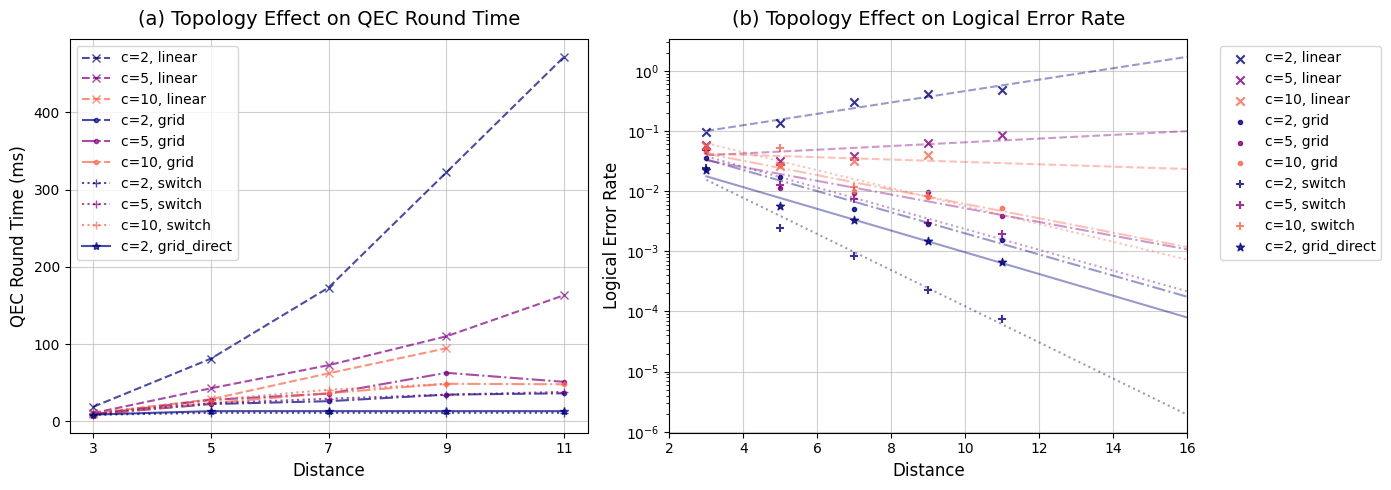

In [21]:
import json
import numpy as np
import matplotlib.pyplot as plt

def load_data(filepath):
    with open(filepath, 'r') as f:
        return json.load(f)

# Load data (Replace the grid_alt path with your actual new file)
grid_data = load_data(r'.\data\topologytestdata\grid_666_d3-15_tc2-10.json')
grid_alt_data = load_data(r'.\data\direct_coord_dist3CCnew.json') 
linear_data = load_data(r'.\data\topologytestdata\linear_666_d3-11_tc2-30new.json') 
switch_data = load_data(r'.\data\topologytestdata\networked_666_d3-11_tc2-30.json') 

# Configuration vars
target_capacities = ['2', '5', '10']
target_distances = [3, 5, 7, 9, 11]
factor_idx = 2  # 0 = 1.0x, 1 = 2.5x, 2 = 5.0x

extrapolate_distance = 16

colors = {'2': 'navy', '5': 'purple', '10': 'tomato'}
markers = {'linear': 'x', 'grid': '.', 'switch': '+', 'grid_direct': '*'}
linestyles = {'linear': '--', 'grid': '-.', 'switch': ':', 'grid_direct': '-'}

def extract_metric(data, metric, distances, capacities, factor_index=None):
    """Safely extracts metrics, returning valid distances and their corresponding values."""
    extracted = {cap: {'d': [], 'val': []} for cap in capacities}
    
    for d in distances:
        d_str = str(d)
        if d_str in data[metric]['Forwarding']:
            for cap in capacities:
                if cap in data[metric]['Forwarding'][d_str]:
                    val = data[metric]['Forwarding'][d_str][cap]
                    if factor_index is not None:
                        if isinstance(val, list) and len(val) > factor_index:
                            val = val[factor_index]
                        else:
                            continue
                            
                    extracted[cap]['d'].append(d)
                    extracted[cap]['val'].append(val)
                    
    return extracted

# Extract standard topologies
grid_times = extract_metric(grid_data, 'ElapsedTime', target_distances, target_capacities)
linear_times = extract_metric(linear_data, 'ElapsedTime', target_distances, target_capacities)
switch_times = extract_metric(switch_data, 'ElapsedTime', target_distances, target_capacities)
grid_errors = extract_metric(grid_data, 'LogicalErrorRates', target_distances, target_capacities, factor_idx)
linear_errors = extract_metric(linear_data, 'LogicalErrorRates', target_distances, target_capacities, 1)
switch_errors = extract_metric(switch_data, 'LogicalErrorRates', target_distances, target_capacities, factor_idx)

# Extract ONLY capacity '2' for the alternate mapping
grid_alt_times = extract_metric(grid_alt_data, 'ElapsedTime', target_distances, ['2'])
grid_alt_errors = extract_metric(grid_alt_data, 'LogicalErrorRates', target_distances, ['2'], 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

def plot_times(time_dict, topo_name):
    for cap in target_capacities:
        # Use .get() to avoid KeyError if a dataset (like grid_alt) doesn't have all capacities
        cap_data = time_dict.get(cap, {'d': [], 'val': []})
        if len(cap_data['d']) > 0:
            vals_ms = [v * 1000 for v in cap_data['val']]
            ax1.plot(cap_data['d'], vals_ms, color=colors[cap], marker=markers[topo_name], 
                     linestyle=linestyles[topo_name], label=f'c={cap}, {topo_name}', alpha=0.7)

plot_times(linear_times, 'linear')
plot_times(grid_times, 'grid')
plot_times(switch_times, 'switch')
plot_times(grid_alt_times, 'grid_direct')

ax1.set_title('(a) Topology Effect on QEC Round Time', fontsize=14, pad=10)
ax1.set_xlabel('Distance', fontsize=12)
ax1.set_ylabel('QEC Round Time (ms)', fontsize=12)
ax1.set_xticks(target_distances)
ax1.grid(True, linestyle='-', alpha=0.6)
ax1.legend()

def plot_error_fit(data_dict, topo_name):
    for cap in target_capacities:
        cap_data = data_dict.get(cap, {'d': [], 'val': []})
        d_vals = np.array(cap_data['d'])
        p_vals = np.array(cap_data['val'])
        
        if len(d_vals) > 0:
            ax2.scatter(d_vals, p_vals, color=colors[cap], marker=markers[topo_name], alpha=0.8, label=f'c={cap}, {topo_name}')
            
            if len(d_vals) >= 2:
                valid_mask = p_vals > 0
                if sum(valid_mask) >= 2:
                    m, c = np.polyfit(d_vals[valid_mask], np.log10(p_vals[valid_mask]), 1)
                    
                    extended_d_vals = np.linspace(min(d_vals), extrapolate_distance, 50)
                    extended_fit_vals = 10**(m * extended_d_vals + c)
                    
                    ax2.plot(extended_d_vals, extended_fit_vals, color=colors[cap], 
                             linestyle=linestyles[topo_name], alpha=0.4)

plot_error_fit(linear_errors, 'linear')
plot_error_fit(grid_errors, 'grid')
plot_error_fit(switch_errors, 'switch')
plot_error_fit(grid_alt_errors, 'grid_direct')

ax2.set_title('(b) Topology Effect on Logical Error Rate', fontsize=14, pad=10)
ax2.set_xlabel('Distance', fontsize=12)
ax2.set_ylabel('Logical Error Rate', fontsize=12)

ax2.set_xlim(2, extrapolate_distance)
ax2.set_xticks(np.arange(2, extrapolate_distance + 1, 2)) 

ax2.set_yscale('log')
ax2.grid(True, linestyle='-', alpha=0.6)

# Use bbox_to_anchor to push the larger legend outside the plot area if it overlaps
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
output_filename = "architecture_effect_plots_gi_5xnew.png"
plt.savefig(output_filename, dpi=300)
plt.show()

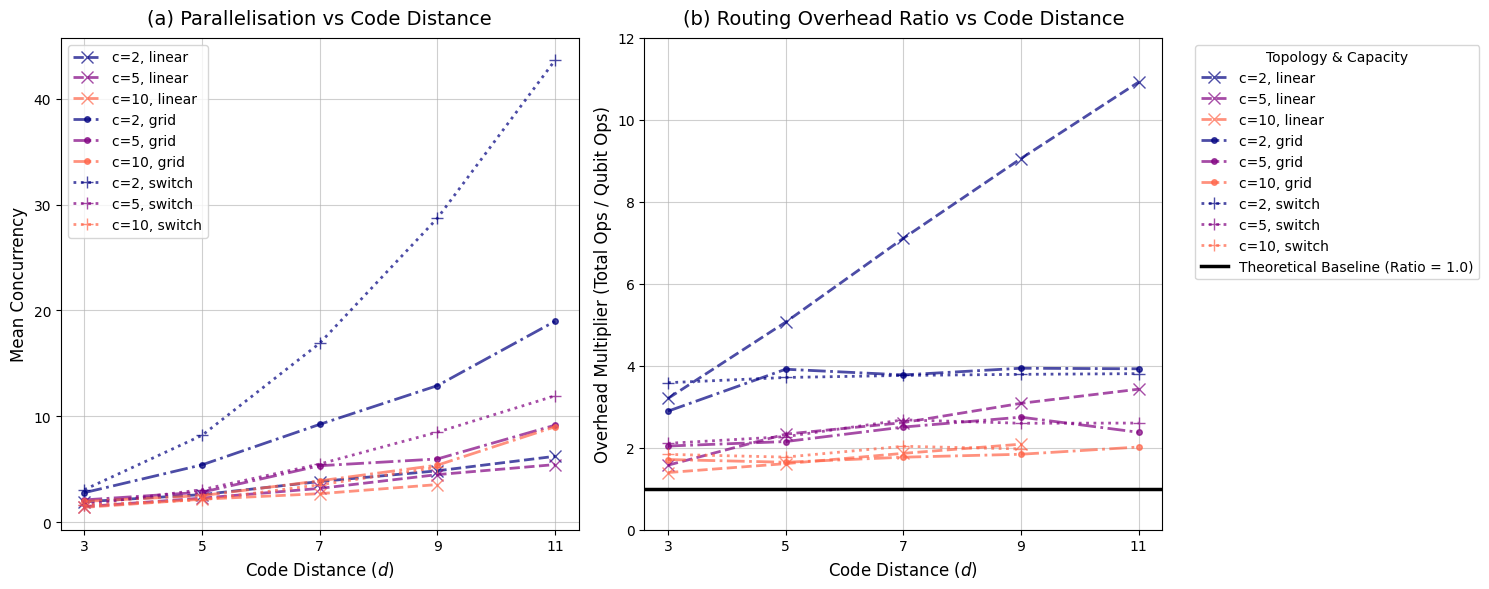

In [22]:

def compute_overhead_ratio(ops_data, q_ops_data):
    """Calculates Overhead Ratio = Total Operations / Qubit Operations"""
    ratio = {cap: {'d': [], 'val': []} for cap in target_capacities}
    
    for cap in target_capacities:
        for d, op_val, q_op_val in zip(ops_data[cap]['d'], ops_data[cap]['val'], q_ops_data[cap]['val']):
            if q_op_val > 0:  # Prevent division by zero
                ratio[cap]['d'].append(d)
                ratio[cap]['val'].append(op_val / q_op_val)
                
    return ratio

grid_concurrency = extract_metric(grid_data, 'MeanConcurrency', target_distances, target_capacities)
linear_concurrency = extract_metric(linear_data, 'MeanConcurrency', target_distances, target_capacities)
switch_concurrency = extract_metric(switch_data, 'MeanConcurrency', target_distances, target_capacities)

grid_ops = extract_metric(grid_data, 'Operations', target_distances, target_capacities)
linear_ops = extract_metric(linear_data, 'Operations', target_distances, target_capacities)
switch_ops = extract_metric(switch_data, 'Operations', target_distances, target_capacities)

grid_q_ops = extract_metric(grid_data, 'QubitOperations', target_distances, target_capacities)
linear_q_ops = extract_metric(linear_data, 'QubitOperations', target_distances, target_capacities)
switch_q_ops = extract_metric(switch_data, 'QubitOperations', target_distances, target_capacities)

grid_ratio = compute_overhead_ratio(grid_ops, grid_q_ops)
linear_ratio = compute_overhead_ratio(linear_ops, linear_q_ops)
switch_ratio = compute_overhead_ratio(switch_ops, switch_q_ops)

fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(15, 6))

def plot_custom_metric(ax, data_dict, topo_name):
    for cap in target_capacities:
        if len(data_dict[cap]['d']) > 0:
            ax.plot(data_dict[cap]['d'], data_dict[cap]['val'], color=colors[cap], 
                    marker=markers[topo_name], linestyle=linestyles[topo_name], 
                    label=f'c={cap}, {topo_name}', alpha=0.7, linewidth=2, markersize=8)

plot_custom_metric(ax3, linear_concurrency, 'linear')
plot_custom_metric(ax3, grid_concurrency, 'grid')
plot_custom_metric(ax3, switch_concurrency, 'switch')

ax3.set_title('(a) Parallelisation vs Code Distance', fontsize=14, pad=10)
ax3.set_xlabel('Code Distance ($d$)', fontsize=12)
ax3.set_ylabel('Mean Concurrency', fontsize=12)
ax3.set_xticks(target_distances)
ax3.grid(True, linestyle='-', alpha=0.6)
ax3.legend()

plot_custom_metric(ax4, linear_ratio, 'linear')
plot_custom_metric(ax4, grid_ratio, 'grid')
plot_custom_metric(ax4, switch_ratio, 'switch')

ax4.axhline(y=1.0, color='black', linestyle='-', linewidth=2.5, label='Theoretical Baseline (Ratio = 1.0)')

ax4.set_title('(b) Routing Overhead Ratio vs Code Distance', fontsize=14, pad=10)
ax4.set_xlabel('Code Distance ($d$)', fontsize=12)
ax4.set_ylabel('Overhead Multiplier (Total Ops / Qubit Ops)', fontsize=12)
ax4.set_xticks(target_distances)
ax4.set_ylim(0,12)
#ax4.set_yscale('log')
ax4.grid(True, which='both', linestyle='-', alpha=0.6)

ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Topology & Capacity")

plt.tight_layout()
plt.savefig('architecture_parallel_routing_effect.png')
plt.show()

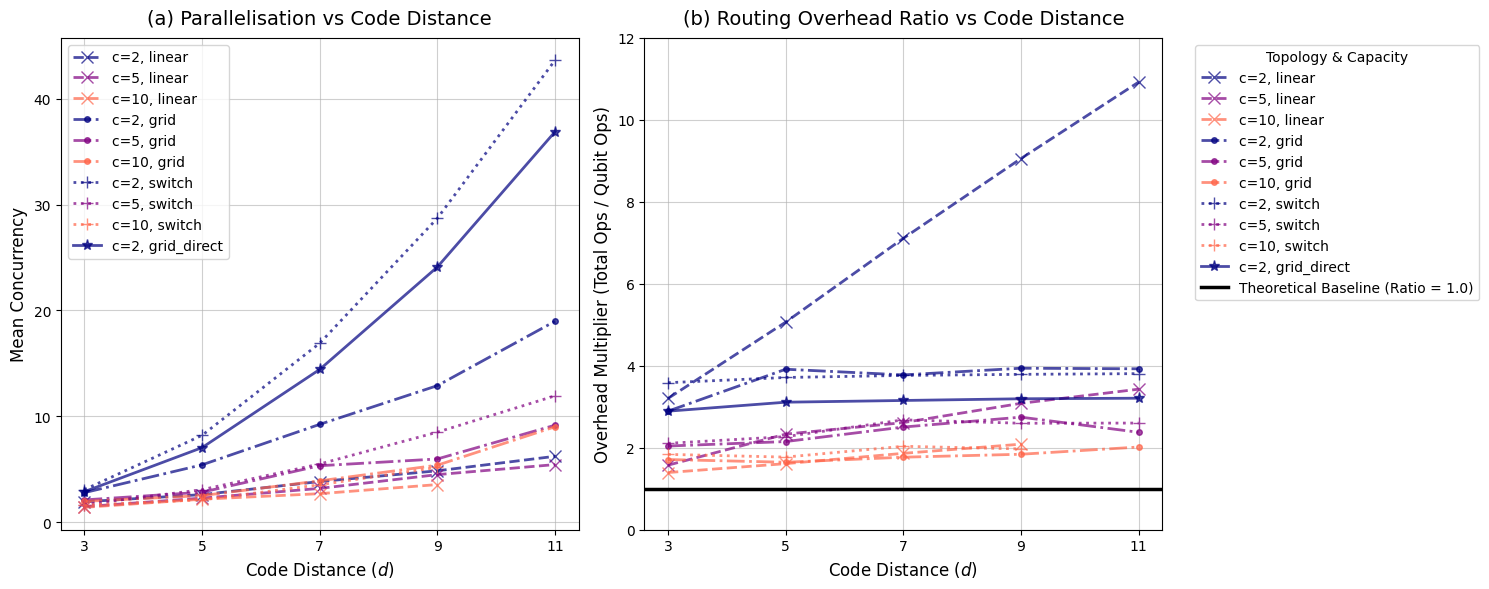

In [24]:
def compute_overhead_ratio(ops_data, q_ops_data):
    """Calculates Overhead Ratio = Total Operations / Qubit Operations"""
    ratio = {cap: {'d': [], 'val': []} for cap in target_capacities}
    
    for cap in target_capacities:
        # Use .get() to safely handle datasets (like grid_alt) that don't have all capacities
        cap_ops = ops_data.get(cap, {'d': [], 'val': []})
        cap_q_ops = q_ops_data.get(cap, {'d': [], 'val': []})
        
        for d, op_val, q_op_val in zip(cap_ops['d'], cap_ops['val'], cap_q_ops['val']):
            if q_op_val > 0:  # Prevent division by zero
                ratio[cap]['d'].append(d)
                ratio[cap]['val'].append(op_val / q_op_val)
                
    return ratio

# --- 1. Extract Concurrency ---
grid_concurrency = extract_metric(grid_data, 'MeanConcurrency', target_distances, target_capacities)
linear_concurrency = extract_metric(linear_data, 'MeanConcurrency', target_distances, target_capacities)
switch_concurrency = extract_metric(switch_data, 'MeanConcurrency', target_distances, target_capacities)
grid_alt_concurrency = extract_metric(grid_alt_data, 'MeanConcurrency', target_distances, ['2'])

# --- 2. Extract Operations ---
grid_ops = extract_metric(grid_data, 'Operations', target_distances, target_capacities)
linear_ops = extract_metric(linear_data, 'Operations', target_distances, target_capacities)
switch_ops = extract_metric(switch_data, 'Operations', target_distances, target_capacities)
grid_alt_ops = extract_metric(grid_alt_data, 'Operations', target_distances, ['2'])

grid_q_ops = extract_metric(grid_data, 'QubitOperations', target_distances, target_capacities)
linear_q_ops = extract_metric(linear_data, 'QubitOperations', target_distances, target_capacities)
switch_q_ops = extract_metric(switch_data, 'QubitOperations', target_distances, target_capacities)
grid_alt_q_ops = extract_metric(grid_alt_data, 'QubitOperations', target_distances, ['2'])

# --- 3. Compute Ratios ---
grid_ratio = compute_overhead_ratio(grid_ops, grid_q_ops)
linear_ratio = compute_overhead_ratio(linear_ops, linear_q_ops)
switch_ratio = compute_overhead_ratio(switch_ops, switch_q_ops)
grid_alt_ratio = compute_overhead_ratio(grid_alt_ops, grid_alt_q_ops)

# --- 4. Plotting ---
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(15, 6))

def plot_custom_metric(ax, data_dict, topo_name):
    for cap in target_capacities:
        # Use .get() to safely extract the data for the current capacity
        cap_data = data_dict.get(cap, {'d': [], 'val': []})
        
        if len(cap_data['d']) > 0:
            ax.plot(cap_data['d'], cap_data['val'], color=colors[cap], 
                    marker=markers[topo_name], linestyle=linestyles[topo_name], 
                    label=f'c={cap}, {topo_name}', alpha=0.7, linewidth=2, markersize=8)

# Panel (a): Concurrency
plot_custom_metric(ax3, linear_concurrency, 'linear')
plot_custom_metric(ax3, grid_concurrency, 'grid')
plot_custom_metric(ax3, switch_concurrency, 'switch')
plot_custom_metric(ax3, grid_alt_concurrency, 'grid_direct')

ax3.set_title('(a) Parallelisation vs Code Distance', fontsize=14, pad=10)
ax3.set_xlabel('Code Distance ($d$)', fontsize=12)
ax3.set_ylabel('Mean Concurrency', fontsize=12)
ax3.set_xticks(target_distances)
ax3.grid(True, linestyle='-', alpha=0.6)
ax3.legend()

# Panel (b): Routing Overhead Ratio
plot_custom_metric(ax4, linear_ratio, 'linear')
plot_custom_metric(ax4, grid_ratio, 'grid')
plot_custom_metric(ax4, switch_ratio, 'switch')
plot_custom_metric(ax4, grid_alt_ratio, 'grid_direct')

ax4.axhline(y=1.0, color='black', linestyle='-', linewidth=2.5, label='Theoretical Baseline (Ratio = 1.0)')

ax4.set_title('(b) Routing Overhead Ratio vs Code Distance', fontsize=14, pad=10)
ax4.set_xlabel('Code Distance ($d$)', fontsize=12)
ax4.set_ylabel('Overhead Multiplier (Total Ops / Qubit Ops)', fontsize=12)
ax4.set_xticks(target_distances)
ax4.set_ylim(0, 12)
#ax4.set_yscale('log')
ax4.grid(True, which='both', linestyle='-', alpha=0.6)

# Legend placed outside to avoid cluttering
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Topology & Capacity")

plt.tight_layout()
plt.savefig('architecture_parallel_routing_effectnew.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:

def load_and_flatten_data(grid_filepath, linear_filepath, target_factor_idx=2):
    """
    Parses nested JSON QEC data into a flat Pandas DataFrame for easy analysis.
    target_factor_idx: 0 for 1.0x, 1 for 2.5x, 2 for 5.0x gate improvement.
    """
    with open(grid_filepath, 'r') as f:
        grid_data = json.load(f)
    with open(linear_filepath, 'r') as f:
        linear_data = json.load(f)
        
    records = []
    
    def process_topology(data, topo_name):
        distances = data['ElapsedTime']['Forwarding'].keys()
        
        for d_str in distances:
            d = int(d_str)
            capacities = data['ElapsedTime']['Forwarding'][d_str].keys()
            
            for cap_str in capacities:
                cap = int(cap_str)
                
                try:
                    elapsed = data['ElapsedTime']['Forwarding'][d_str][cap_str]
                    ops = data['Operations']['Forwarding'][d_str][cap_str]
                    concurrency = data['MeanConcurrency']['Forwarding'][d_str][cap_str]
                    
                    err_rates = data['LogicalErrorRates']['Forwarding'].get(d_str, {}).get(cap_str, [])
                    log_err = err_rates[target_factor_idx] if len(err_rates) > target_factor_idx else None
                    
                    if log_err is not None:
                        records.append({
                            'Topology': topo_name,
                            'Distance': d,
                            'Capacity': cap,
                            'Elapsed Time (ms)': elapsed * 1000,
                            'Routing Operations': ops,
                            'Mean Concurrency': concurrency,
                            'Logical Error Rate': log_err
                        })
                except KeyError:
                    continue

    process_topology(grid_data, 'Grid')
    process_topology(linear_data, 'Linear')
    
    df = pd.DataFrame(records)
    df = df[df['Distance'].isin([3, 5, 7, 9, 11])]
    df = df[df['Capacity'].isin([2, 5, 10])]
    
    return df

def generate_analytical_dashboard(df):
    """Generates a 2x2 grid of plots to analyze architectural trade-offs."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    sns.set_theme(style="whitegrid")
    
    palette = "Set1"
    style = "Topology"
    markers = True
    
    # Elapsed Time vs Distance
    sns.lineplot(data=df, x='Distance', y='Elapsed Time (ms)', hue='Capacity', 
                 style=style, markers=markers, palette=palette, ax=axes[0, 0], linewidth=2, markersize=8)
    axes[0, 0].set_title('1. QEC Round Time (The Observation)', fontsize=14)
    axes[0, 0].set_ylabel('Elapsed Time (ms)')
    
    # Concurrency vs Distance
    sns.lineplot(data=df, x='Distance', y='Mean Concurrency', hue='Capacity', 
                 style=style, markers=markers, palette=palette, ax=axes[0, 1], linewidth=2, markersize=8)
    axes[0, 1].set_title('2. Parallelization (The Explanation)', fontsize=14)
    axes[0, 1].set_ylabel('Mean Concurrency')
    
    # Operations vs Distance
    sns.lineplot(data=df, x='Distance', y='Routing Operations', hue='Capacity', 
                 style=style, markers=markers, palette=palette, ax=axes[1, 0], linewidth=2, markersize=8)
    axes[1, 0].set_title('3. Routing Overhead', fontsize=14)
    axes[1, 0].set_ylabel('Total Operations')
    
    # Time vs Accuracy
    sns.scatterplot(data=df, x='Elapsed Time (ms)', y='Logical Error Rate', hue='Capacity', 
                    style=style, size='Distance', sizes=(50, 200), palette=palette, ax=axes[1, 1], alpha=0.8)
    axes[1, 1].set_title('4. Time vs. Accuracy Trade-off', fontsize=14)
    axes[1, 1].set_yscale('log')
    
    plt.suptitle('QEC Mapping Architecture Analysis (Gate Improvement: 5.0x)', fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()



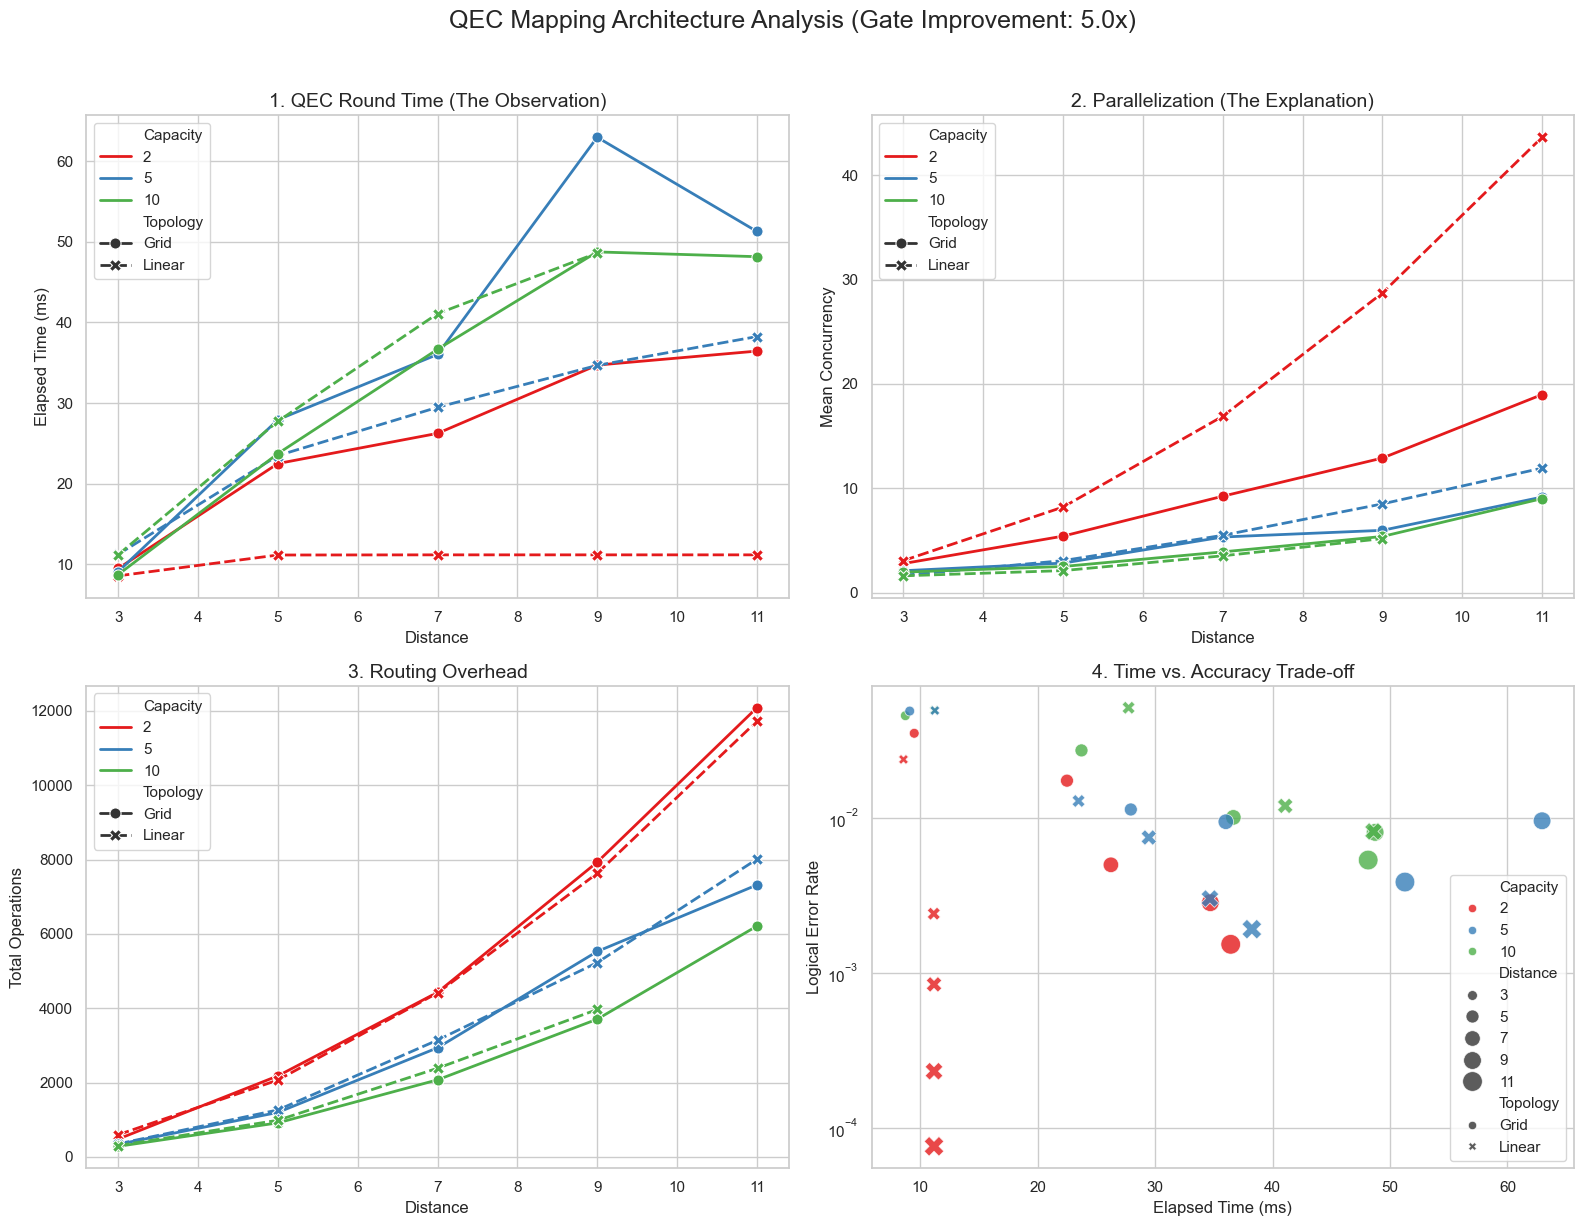

In [23]:

grid_data = r'.\data\topologytestdata\grid_666_d3-15_tc2-10.json'
linear_data = r'.\data\topologytestdata\networked_666_d3-11_tc2-30.json'

# 0 for 1.0x or 1 for 2.5x, 2=5.0x
df = load_and_flatten_data(grid_data, linear_data, target_factor_idx=2)


generate_analytical_dashboard(df)

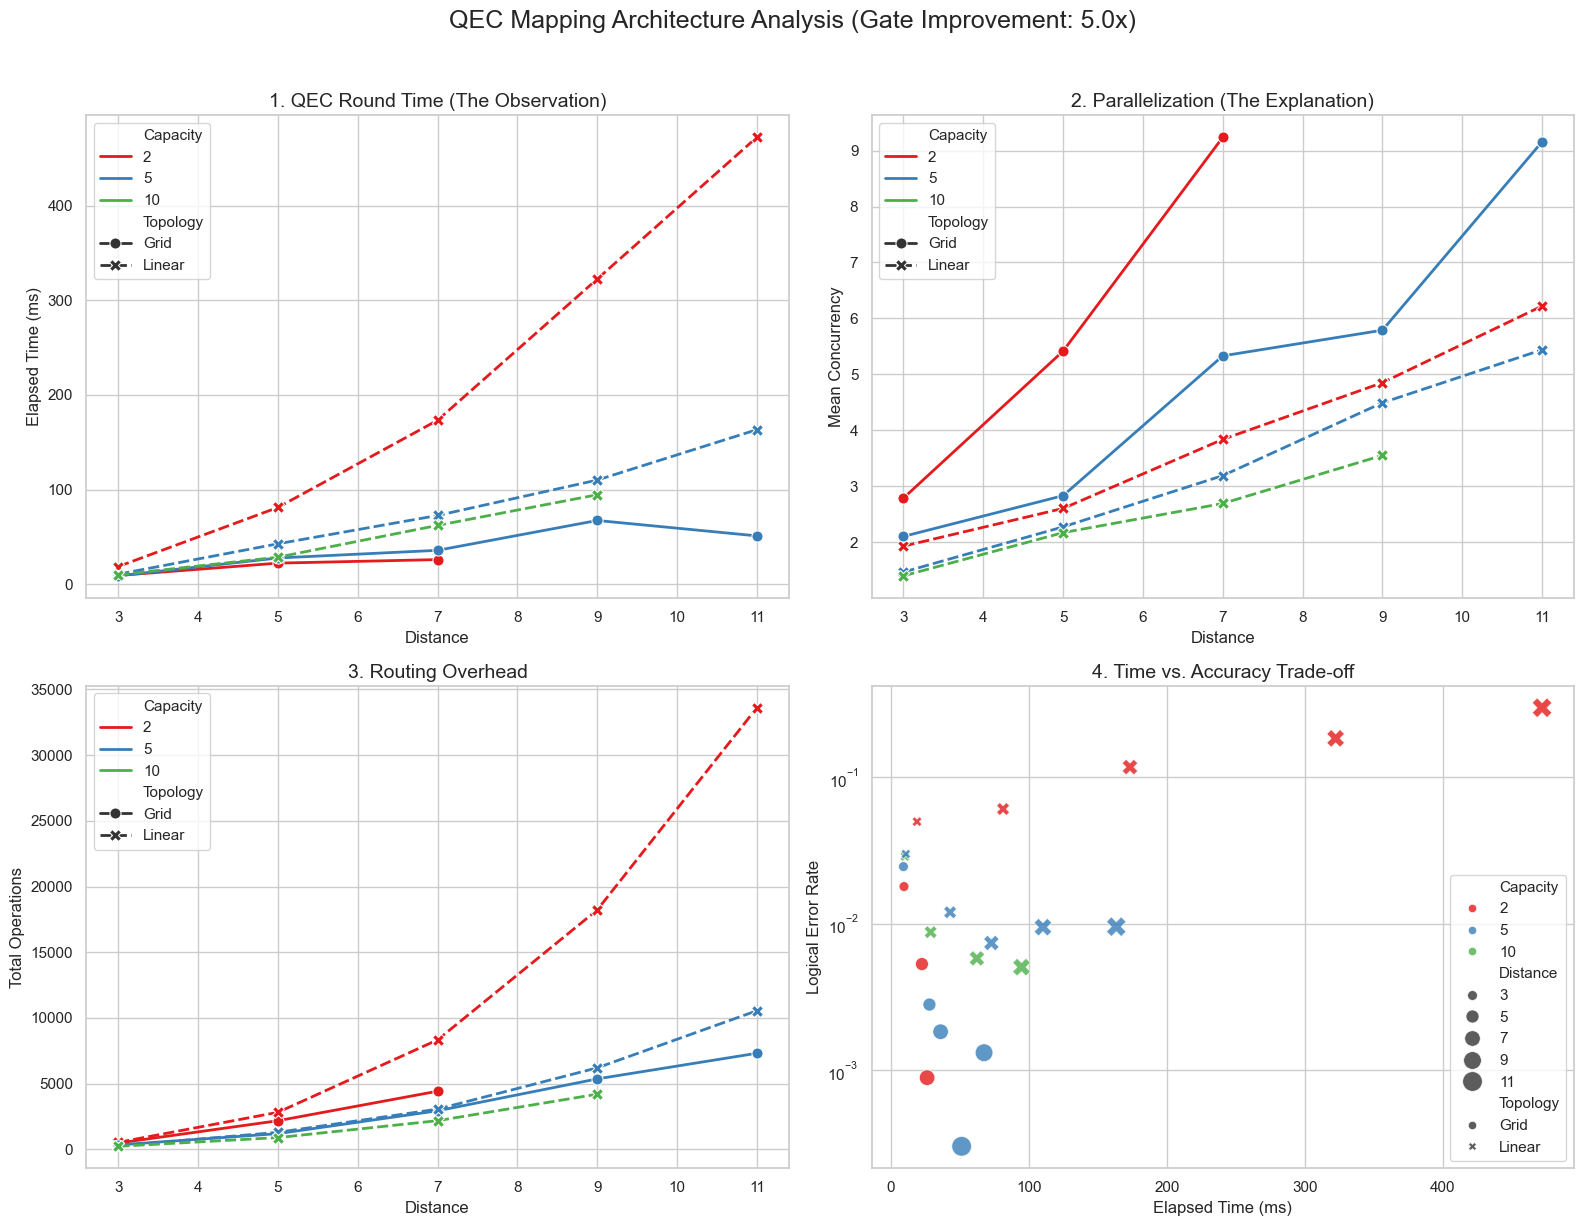

In [25]:

grid_data = r'.\data\topologytestdata\grid_666_d3-11_tc2-30new.json'
linear_data = r'.\data\topologytestdata\linear_666_d3-11_tc2-30new.json'

# 2 = 10x
df = load_and_flatten_data(grid_data, linear_data, target_factor_idx=2)


generate_analytical_dashboard(df)

In [32]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm

def generate_dashboard(json_filepath, savefile=None):
    """
    Generates a 2x2 dashboard analyzing round time and extrapolated logical error rates.
    """
    # ==========================================
    # CONFIGURATION SECTION (EDIT THESE VALUES)
    # ==========================================
    
    # 1. Capacities to show in Plot (a) - Round Time
    time_capacities = [2, 3, 5, 10, 15, 60] 
    
    # 2. Capacities to show in Plots (b, c, d) - Extrapolations
    error_capacities = [2, 10, 15, 60] 
    
    # 3. Gate Improvements for Plots (b, c, d)
    # Format: (List Index in JSON, 'Title Label')
    # Based on your prompt: [1.0, 5.0, 10.0, 15.0] -> indices 0, 1, 2, 3
    improvements = [
        (0, '1x'),
        (2, '10x'),
        (3, '15x')
    ]
    
    # 4. Extrapolation Settings
    max_distance = 20
    y_min, y_max = 1e-10, 1e0  # Fixed 10^-9 to 10^0 range
    
    # ==========================================

    # Load Data
    with open(json_filepath, 'r') as f:
        data = json.load(f)

    times = data.get('ElapsedTime', {}).get('Forwarding', {})
    log_errs = data.get('LogicalErrorRates', {}).get('Forwarding', {})
    distances = sorted([int(d) for d in log_errs.keys()])

    # Initialize Figure
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    
    # Custom color palettes
    time_colors = cm.magma(np.linspace(0.2, 0.8, len(time_capacities)))
    extrap_colors = ['navy', '#A77BB5', '#EAA78C', 'hotpink', 'green'] # Match reference image
    
    # ---------------------------------------------------------
    # Plot (a): Effect of Code Distance on Round Time
    # ---------------------------------------------------------
    ax_a = axes[0, 0]
    
    for i, cap in enumerate(time_capacities):
        cap_str = str(cap)
        x_vals, y_vals = [], []
        for d in distances:
            d_str = str(d)
            if cap_str in times.get(d_str, {}):
                x_vals.append(d)
                y_vals.append(times[d_str][cap_str] * 1000) # Convert to ms
        
        if x_vals:
            ax_a.plot(x_vals, y_vals, color=time_colors[i], marker='.', 
                      linewidth=1.5, markersize=6, label=f'c={cap}', alpha=0.8)

    # Optional: Add Dummy Bound lines (Replace with your theoretical models if needed)
    dist_array = np.array(distances)
    #ax_a.plot(dist_array, [5] * len(dist_array), color='gray', linestyle='--', linewidth=1, label='Lower Bound')
    #ax_a.plot(dist_array, dist_array ** 2.1, color='gray', linestyle='-', linewidth=1, label='Upper Bound')

    ax_a.set_title('(a) Effect of Code Distance on Round Time', fontsize=16, pad=10)
    ax_a.set_xlabel('Distance', fontsize=12)
    ax_a.set_ylabel('Time (ms)', fontsize=12)
    ax_a.set_xticks(np.arange(2, max(distances)+2, 1))
    ax_a.grid(True, linestyle='-', alpha=0.5)
    ax_a.legend(loc='upper left', fontsize=11)


    # ---------------------------------------------------------
    # Plots (b), (c), (d): Extrapolated Logical Error Rates
    # ---------------------------------------------------------
    extrap_axes = [axes[0, 1], axes[1, 0], axes[1, 1]]
    panel_labels = ['(b)', '(c)', '(d)']
    
    for ax_idx, (factor_idx, label_mult) in enumerate(improvements):
        ax = extrap_axes[ax_idx]
        
        for c_idx, cap in enumerate(error_capacities):
            cap_str = str(cap)
            c_color = extrap_colors[c_idx % len(extrap_colors)]
            
            x_vals, y_vals = [], []
            for d in distances:
                d_str = str(d)
                if cap_str in log_errs.get(d_str, {}):
                    err_list = log_errs[d_str][cap_str]
                    if len(err_list) > factor_idx and err_list[factor_idx] > 0:
                        x_vals.append(d)
                        y_vals.append(err_list[factor_idx])
            
            if x_vals:
                x_vals = np.array(x_vals)
                y_vals = np.array(y_vals)
                
                ax.scatter(x_vals, y_vals, color=c_color, s=20, alpha=0.9, zorder=3)
                
                if len(x_vals) >= 2:
                    log_y = np.log10(y_vals)
                    m, c = np.polyfit(x_vals, log_y, 1)
                    
                    ext_x = np.linspace(0.5, max_distance, 50)
                    ext_y = 10**(m * ext_x + c)
                    ax.plot(ext_x, ext_y, color=c_color, linestyle='--', linewidth=1.2, zorder=4)
                    
                    std_err = np.std(log_y - (m * x_vals + c))
                    std_err = max(std_err, 0.25) 
                    
                    lower = 10**(m * ext_x + c - std_err)
                    upper = 10**(m * ext_x + c + std_err)
                    ax.fill_between(ext_x, lower, upper, color=c_color, alpha=0.4, edgecolor='none', zorder=2)


        ax.set_title(f'{panel_labels[ax_idx]} Distance Needed at {label_mult} Improvement', fontsize=16, pad=10)
        ax.set_xlabel('Distance', fontsize=12)
        ax.set_ylabel('Logical Error Rate', fontsize=12)
        ax.set_yscale('log')
        

        ax.set_xlim(0.5, max_distance)
        if factor_idx != 0:
            ax.set_ylim(y_min, y_max)
        
        ax.set_xticks(np.arange(2, max_distance + 1, 2))
        ax.grid(True, which='major', linestyle='-', alpha=0.5)
        
        handles = [mpatches.Patch(color=extrap_colors[i % len(extrap_colors)], alpha=0.5, label=f'c={cap}') 
                   for i, cap in enumerate(error_capacities)]
        
        loc = 'lower left' if ax_idx == 1 else 'upper right'
        ax.legend(handles=handles, loc=loc, fontsize=11, framealpha=0.9)

    plt.tight_layout()
    if savefile is not None:
        plt.savefig(savefile, dpi=300, bbox_inches='tight')
    plt.show()



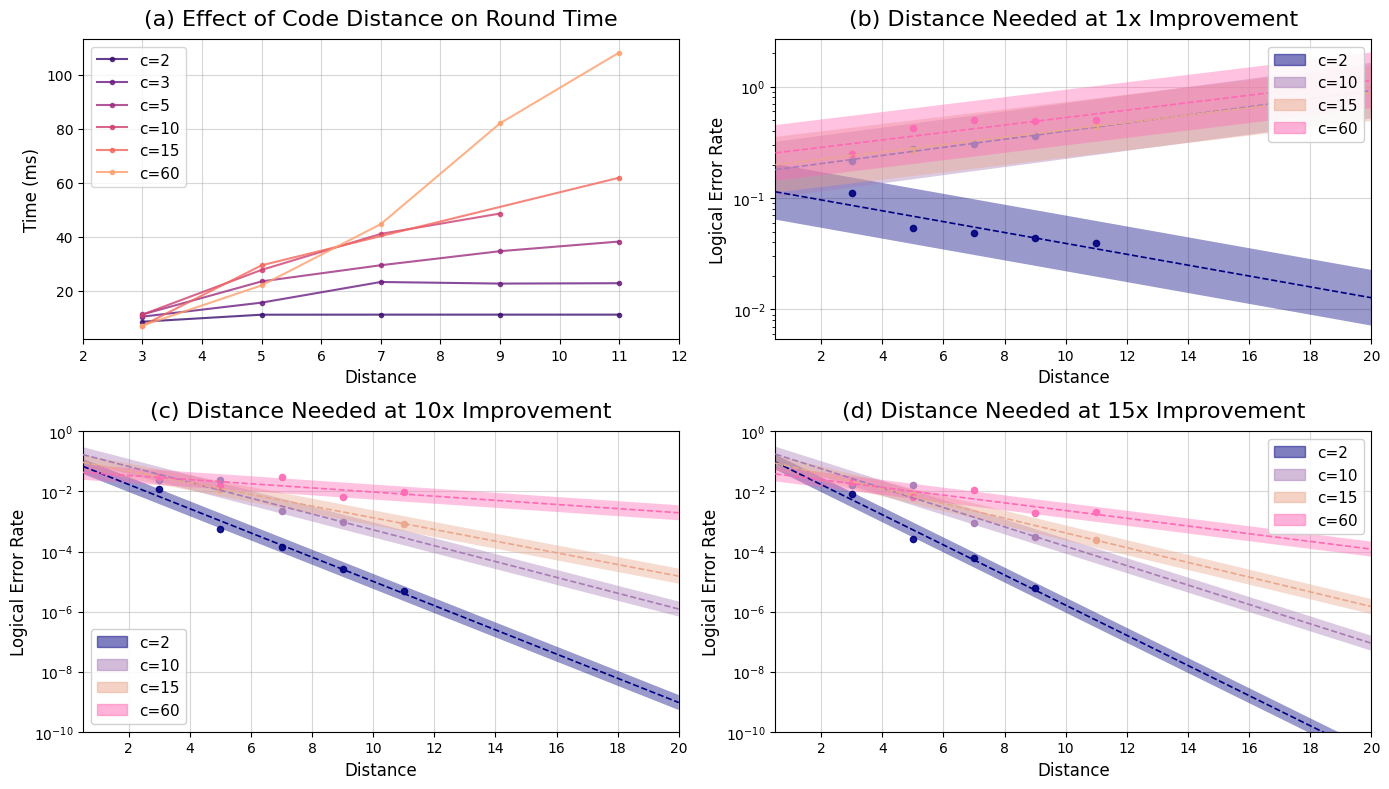

In [33]:
# --- Example Usage ---
cc488_grid_data = r'.\data\tctests\tctestgrid488.json'
cc488_switch_data = r'.\data\tctests\tctestswitch488maybe.json'
cc666_grid_data = r'.\data\tctests\tcgrid666.json'
cc666_switch_data = r'.\data\tctests\tcswitch666.json'
#generate_dashboard(cc666_grid_data, 'tc_cc666_grid_data.png')
generate_dashboard(cc666_switch_data, 'tc_cc666_switch_data.png')

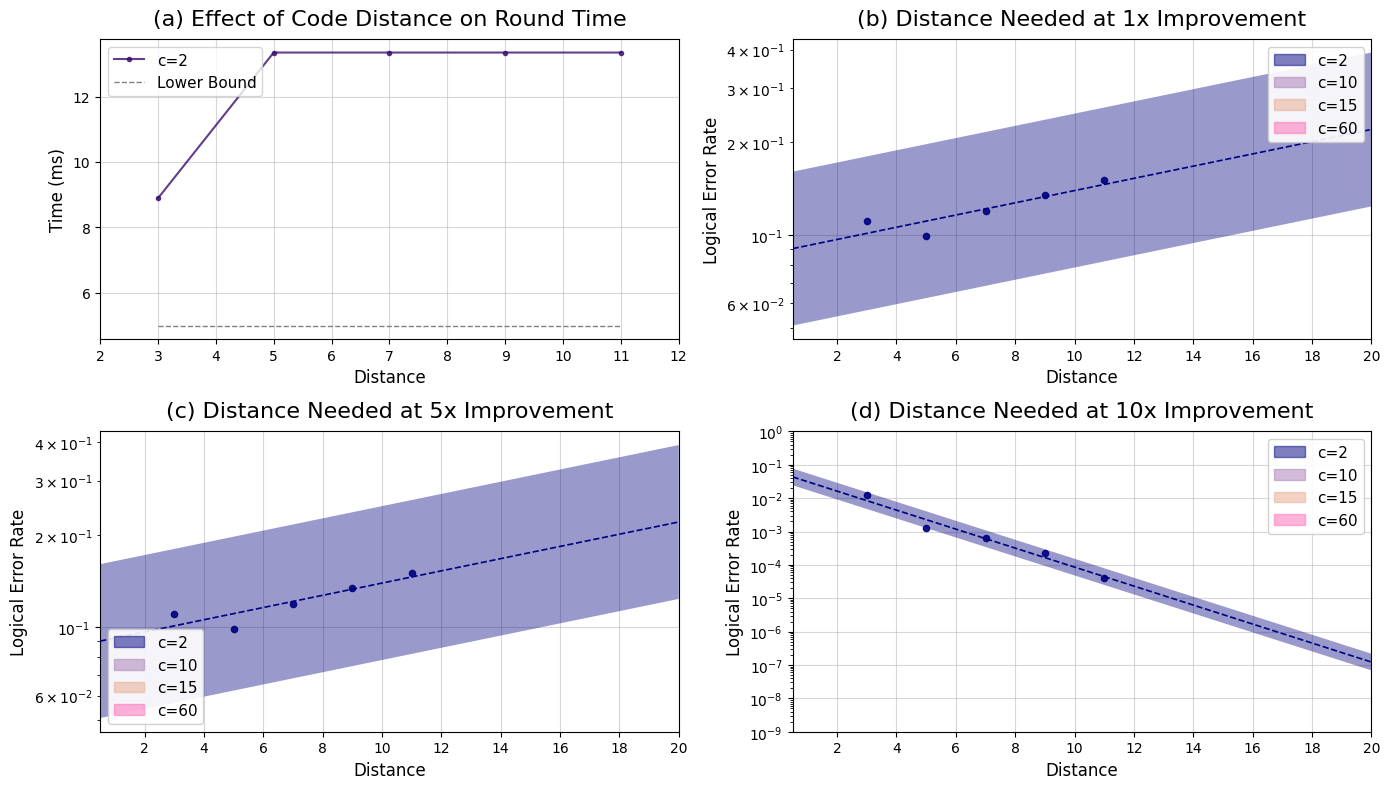

In [27]:
path = r'.\data\direct_coord_dist3CCnew.json'
generate_dashboard(path)

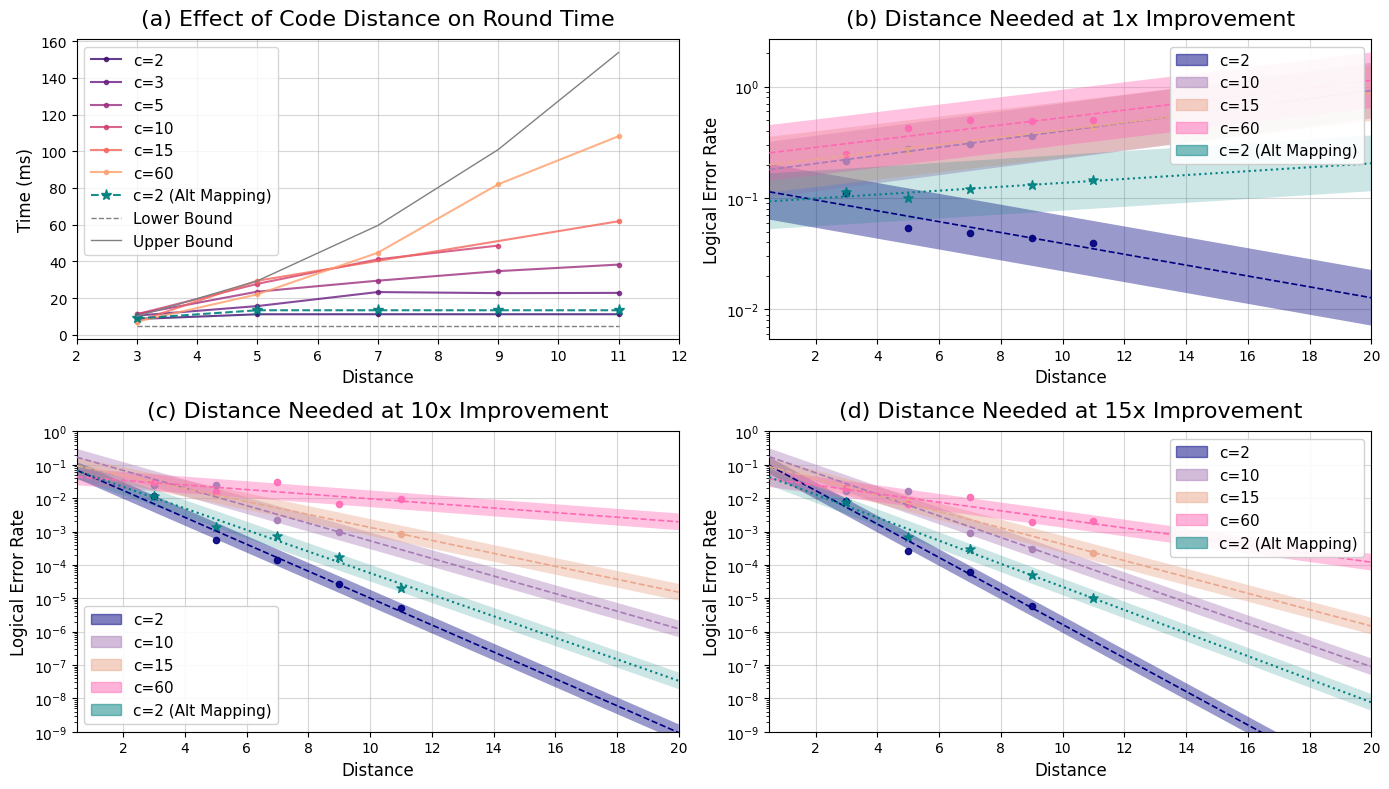

In [19]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm

def generate_dashboard(json_filepath, alt_json_filepath=None, savefile=None):
    """
    Generates a 2x2 dashboard analyzing round time and extrapolated logical error rates.
    Includes an optional alternate data file for comparing a different c=2 mapping.
    """
    # ==========================================
    # CONFIGURATION SECTION
    # ==========================================
    time_capacities = [2, 3, 5, 10, 15, 60] 
    error_capacities = [2, 10, 15, 60] 
    
    improvements = [
        (0, '1x'),
        (2, '10x'),
        (3, '15x')
    ]
    
    max_distance = 20
    y_min, y_max = 1e-9, 1e0  
    
    alt_color = 'teal'
    alt_label = 'c=2 (Alt Mapping)'
    
    # ==========================================

    # Load Base Data
    with open(json_filepath, 'r') as f:
        data = json.load(f)
    times = data.get('ElapsedTime', {}).get('Forwarding', {})
    log_errs = data.get('LogicalErrorRates', {}).get('Forwarding', {})
    distances = sorted([int(d) for d in log_errs.keys()])

    # Load Alt Data
    alt_times, alt_log_errs = {}, {}
    if alt_json_filepath:
        with open(alt_json_filepath, 'r') as f:
            alt_data = json.load(f)
        alt_times = alt_data.get('ElapsedTime', {}).get('Forwarding', {})
        alt_log_errs = alt_data.get('LogicalErrorRates', {}).get('Forwarding', {})

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    
    time_colors = cm.magma(np.linspace(0.2, 0.8, len(time_capacities)))
    extrap_colors = ['navy', '#A77BB5', '#EAA78C', 'hotpink', 'green'] 
    
    # ---------------------------------------------------------
    # Plot (a): Effect of Code Distance on Round Time
    # ---------------------------------------------------------
    ax_a = axes[0, 0]
    
    # Base Data
    for i, cap in enumerate(time_capacities):
        cap_str = str(cap)
        x_vals = [d for d in distances if cap_str in times.get(str(d), {})]
        y_vals = [times[str(d)][cap_str] * 1000 for d in x_vals]
        if x_vals:
            ax_a.plot(x_vals, y_vals, color=time_colors[i], marker='.', 
                      linewidth=1.5, markersize=6, label=f'c={cap}', alpha=0.8)

    # Alt Data
    if alt_times:
        alt_x = [d for d in distances if '2' in alt_times.get(str(d), {})]
        alt_y = [alt_times[str(d)]['2'] * 1000 for d in alt_x]
        if alt_x:
            ax_a.plot(alt_x, alt_y, color=alt_color, marker='*', linestyle='--', 
                      linewidth=1.5, markersize=8, label=alt_label, alpha=0.9)

    dist_array = np.array(distances)
    ax_a.plot(dist_array, [5] * len(dist_array), color='gray', linestyle='--', linewidth=1, label='Lower Bound')
    ax_a.plot(dist_array, dist_array ** 2.1, color='gray', linestyle='-', linewidth=1, label='Upper Bound')

    ax_a.set_title('(a) Effect of Code Distance on Round Time', fontsize=16, pad=10)
    ax_a.set_xlabel('Distance', fontsize=12)
    ax_a.set_ylabel('Time (ms)', fontsize=12)
    ax_a.set_xticks(np.arange(2, max(distances)+2, 1))
    ax_a.grid(True, linestyle='-', alpha=0.5)
    ax_a.legend(loc='upper left', fontsize=11)

    # ---------------------------------------------------------
    # Plots (b), (c), (d): Extrapolated Logical Error Rates
    # ---------------------------------------------------------
    extrap_axes = [axes[0, 1], axes[1, 0], axes[1, 1]]
    panel_labels = ['(b)', '(c)', '(d)']
    
    for ax_idx, (factor_idx, label_mult) in enumerate(improvements):
        ax = extrap_axes[ax_idx]
        
        # Base Data
        for c_idx, cap in enumerate(error_capacities):
            cap_str = str(cap)
            c_color = extrap_colors[c_idx % len(extrap_colors)]
            
            x_vals = [d for d in distances if cap_str in log_errs.get(str(d), {}) 
                      and len(log_errs[str(d)][cap_str]) > factor_idx and log_errs[str(d)][cap_str][factor_idx] > 0]
            y_vals = [log_errs[str(d)][cap_str][factor_idx] for d in x_vals]
            
            if x_vals:
                x_vals, y_vals = np.array(x_vals), np.array(y_vals)
                ax.scatter(x_vals, y_vals, color=c_color, s=20, alpha=0.9, zorder=3)
                
                if len(x_vals) >= 2:
                    log_y = np.log10(y_vals)
                    m, c = np.polyfit(x_vals, log_y, 1)
                    ext_x = np.linspace(0.5, max_distance, 50)
                    ax.plot(ext_x, 10**(m * ext_x + c), color=c_color, linestyle='--', linewidth=1.2, zorder=4)
                    
                    std_err = max(np.std(log_y - (m * x_vals + c)), 0.25)
                    ax.fill_between(ext_x, 10**(m * ext_x + c - std_err), 10**(m * ext_x + c + std_err), 
                                    color=c_color, alpha=0.4, edgecolor='none', zorder=2)

        # Alt Data
        if alt_log_errs:
            alt_x = [d for d in distances if '2' in alt_log_errs.get(str(d), {}) 
                     and len(alt_log_errs[str(d)]['2']) > factor_idx and alt_log_errs[str(d)]['2'][factor_idx] > 0]
            alt_y = [alt_log_errs[str(d)]['2'][factor_idx] for d in alt_x]
            
            if alt_x:
                alt_x, alt_y = np.array(alt_x), np.array(alt_y)
                ax.scatter(alt_x, alt_y, color=alt_color, marker='*', s=50, alpha=0.9, zorder=3)
                
                if len(alt_x) >= 2:
                    log_y = np.log10(alt_y)
                    m, c = np.polyfit(alt_x, log_y, 1)
                    ext_x = np.linspace(0.5, max_distance, 50)
                    ax.plot(ext_x, 10**(m * ext_x + c), color=alt_color, linestyle=':', linewidth=1.5, zorder=4)
                    
                    std_err = max(np.std(log_y - (m * alt_x + c)), 0.25)
                    ax.fill_between(ext_x, 10**(m * ext_x + c - std_err), 10**(m * ext_x + c + std_err), 
                                    color=alt_color, alpha=0.2, edgecolor='none', zorder=2)

        # Formatting
        ax.set_title(f'{panel_labels[ax_idx]} Distance Needed at {label_mult} Improvement', fontsize=16, pad=10)
        ax.set_xlabel('Distance', fontsize=12)
        ax.set_ylabel('Logical Error Rate', fontsize=12)
        ax.set_yscale('log')
        ax.set_xlim(0.5, max_distance)
        if factor_idx != 0: ax.set_ylim(y_min, y_max)
        ax.set_xticks(np.arange(2, max_distance + 1, 2))
        ax.grid(True, which='major', linestyle='-', alpha=0.5)
        
        # Custom Legend
        handles = [mpatches.Patch(color=extrap_colors[i % len(extrap_colors)], alpha=0.5, label=f'c={cap}') 
                   for i, cap in enumerate(error_capacities)]
        if alt_log_errs:
            handles.append(mpatches.Patch(color=alt_color, alpha=0.5, label=alt_label))
            
        loc = 'lower left' if ax_idx == 1 else 'upper right'
        ax.legend(handles=handles, loc=loc, fontsize=11, framealpha=0.9)

    plt.tight_layout()
    if savefile:
        plt.savefig(savefile, dpi=300, bbox_inches='tight')
    plt.show()

# --- Example Usage ---
generate_dashboard(json_filepath=r'.\data\tctests\tcswitch666.json', 
                   alt_json_filepath=r'.\data\tctests\tctestdirect_mapped.json')
                   #savefile='dashboard_with_alt.png')

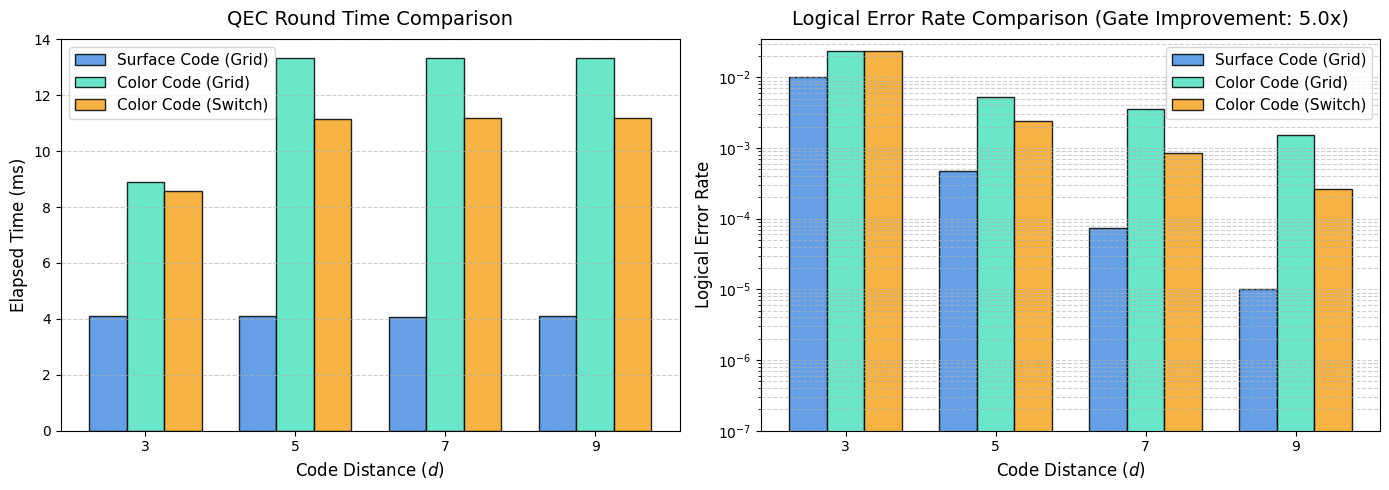

In [12]:
import json
import numpy as np
import matplotlib.pyplot as plt

def load_data(filepath):
    with open(filepath, 'r') as f:
        return json.load(f)

def plot_qec_architecture_comparison(sc_grid_file, cc_grid_file, cc_switch_file):
    #configuration
    target_distances = [3, 5, 7, 9]
    
    # Gate improvement mapping: 0=1.0x, 1=5.0x, 2=10.0x, 3=20.0x
    factor_idx = 1
    factor_label = "5.0x"
    
    trap_capacity = '2'

    sc_grid = load_data(sc_grid_file)
    cc_grid = load_data(cc_grid_file)
    cc_switch = load_data(cc_switch_file)

    labels = ['Surface Code (Grid)', 'Color Code (Grid)', 'Color Code (Switch)']
    colors = ['#4A90E2', '#50E3C2', '#F5A623'] # Blue, Teal, Orange

    def extract(data_dict, metric, distances, cap, f_idx=None):
        vals = []
        for d in distances:
            d_str = str(d)
            try:
                val = data_dict[metric]['Forwarding'][d_str][cap]
                if f_idx is not None:
                    val = val[f_idx]
                vals.append(val if val > 0 else 1e-10) # 1e-10 prevents log-scale errors on 0.0
            except (KeyError, IndexError):
                vals.append(np.nan)
        return vals

    times = [
        np.array(extract(sc_grid, 'ElapsedTime', target_distances, trap_capacity)) * 1000,
        np.array(extract(cc_grid, 'ElapsedTime', target_distances, trap_capacity)) * 1000,
        np.array(extract(cc_switch, 'ElapsedTime', target_distances, trap_capacity)) * 1000
    ]

    lers = [
        extract(sc_grid, 'LogicalErrorRates', target_distances, trap_capacity, factor_idx),
        extract(cc_grid, 'LogicalErrorRates', target_distances, trap_capacity, factor_idx),
        extract(cc_switch, 'LogicalErrorRates', target_distances, trap_capacity, factor_idx)
    ]


    x = np.arange(len(target_distances))
    width = 0.25
    offsets = [-width, 0, width]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # elapsed time plot
    for i, (t_vals, label, color, offset) in enumerate(zip(times, labels, colors, offsets)):
        ax1.bar(x + offset, t_vals, width, label=label, color=color, edgecolor='black', alpha=0.85)

    ax1.set_title('QEC Round Time Comparison', fontsize=14, pad=10)
    ax1.set_xlabel('Code Distance ($d$)', fontsize=12)
    ax1.set_ylabel('Elapsed Time (ms)', fontsize=12)
    ax1.set_xticks(x)
    ax1.set_xticklabels(target_distances)
    ax1.grid(axis='y', linestyle='--', alpha=0.6)
    ax1.legend(fontsize=11)

    # LER plot
    for i, (l_vals, label, color, offset) in enumerate(zip(lers, labels, colors, offsets)):
        ax2.bar(x + offset, l_vals, width, label=label, color=color, edgecolor='black', alpha=0.85)

    ax2.set_title(f'Logical Error Rate Comparison (Gate Improvement: {factor_label})', fontsize=14, pad=10)
    ax2.set_xlabel('Code Distance ($d$)', fontsize=12)
    ax2.set_ylabel('Logical Error Rate', fontsize=12)
    ax2.set_xticks(x)
    ax2.set_xticklabels(target_distances)
    
    ax2.set_yscale('log')
    ax2.set_ylim(bottom=1e-7)
    ax2.grid(axis='y', which='both', linestyle='--', alpha=0.6)
    ax2.legend(fontsize=11)

    plt.tight_layout()
    plt.savefig('sc_cc_comparison_barchart.png')
    plt.show()

sc = r'.\data\sc_cc_comparison\sc_grid\sc_grid_data.json'
cc_grid = r'.\data\sc_cc_comparison\cc_grid_dc\cc_grid_data.json'
cc_switch = r'.\data\sc_cc_comparison\cc_switch\cc_switch_data.json'
plot_qec_architecture_comparison(sc, cc_grid, cc_switch)